> **IITD ACPAIMLDL 07 — Capstone Project**
>
> **Project #24: Home Loan Default Risk**
>
> **Goal:** Predict whether a borrower will default on a loan, handling the high-class imbalance and missing values typical of emerging market financial data. Build base learners like XGBoost, Random Forests, and Logistic Regression. Use a Multi-layer Perceptron (MLP) or Support Vector Machine (SVM) as the meta-learner to combine their predictions.
>
> **Data:** [Kaggle — Home Credit Default Risk](https://www.kaggle.com/competitions/home-credit-default-risk/data)
>
> **Contributors:** Michael Richard, Lepakshi Poonamallee, Shilpi Kumari, Rajesh Kuruva, Harshitha Rudraprakash, Karthik Sudhir, Sreekanth Kumar VLN, Chintan Kansara, Vinayak Tyagi

## Exploratory Data Analysis
> The dataset was examined to understand its structure, class imbalance, missing values, and the relationships between features and the default target variable.

In [9]:
!python.exe -m pip install --upgrade pip
!python -m pip install scikit-learn imbalanced-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [10]:
#################################################################################
################################# Import EDA Libraries ##########################
#################################################################################

In [11]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
#from google.colab import drive

sns.set_theme(style='whitegrid', context='notebook', palette='Set2')
plt.rcParams['figure.dpi'] = 90

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


In [12]:
#################################################################################
################################### Load Raw Dataset ############################
#################################################################################

In [13]:
#Use this if running in Google Colab
#drv = drive.mount('/content/drive')

In [14]:
# NOTE: EDA is performed on the raw training set BEFORE any cleaning,
# feature engineering, or merging. This gives insignt into the raw data.


#train = pd.read_csv('/content/drive/MyDrive/Project#24/data-kaggle/home-credit-default-risk/application_train.csv')
#test  = pd.read_csv('/content/drive/MyDrive/Project#24/data-kaggle/home-credit-default-risk/application_test.csv')

train = pd.read_csv('C:/Users/richardsm/AI-Projects/llm/home-credit-default-risk/home-credit-default-risk/application_train.csv')
test  = pd.read_csv('C:/Users/richardsm/AI-Projects/llm/home-credit-default-risk/home-credit-default-risk/application_test.csv')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)

Train shape: (307511, 122)
Test shape:  (48744, 121)


In [15]:
#################################################################################
######################### Target Variable (Class Imbalance) #####################
#################################################################################

In [16]:
# The dataset is highly imbalanced
print('Count:')
print(train['TARGET'].value_counts())
print()
print('Proportion (%):')
print(train['TARGET'].value_counts(normalize=True) * 100)

Count:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Proportion (%):
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


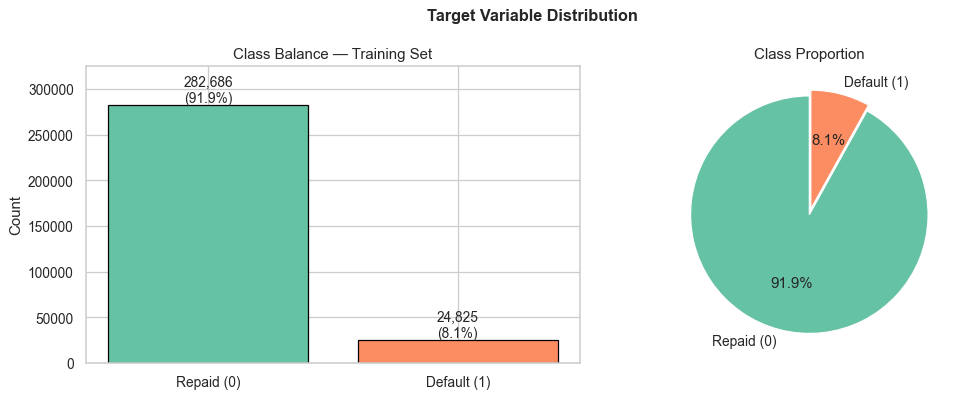

In [17]:
# Charts
counts = pd.Series(train['TARGET']).value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# Bar chart
bars = ax[0].bar(['Repaid (0)', 'Default (1)'], counts.values,
                  color=['#66c2a5', '#fc8d62'], edgecolor='black')
for bar, v in zip(bars, counts.values):
    ax[0].text(bar.get_x() + bar.get_width()/2, v,
               f'{v:,}\n({v/counts.sum()*100:.1f}%)',
               ha='center', va='bottom', fontsize=11)
ax[0].set_title('Class Balance — Training Set')
ax[0].set_ylabel('Count')
ax[0].set_ylim(0, counts.max() * 1.15)

# Pie chart
ax[1].pie(counts.values, labels=['Repaid (0)', 'Default (1)'],
          autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'],
          explode=[0, 0.05], startangle=90)
ax[1].set_title('Class Proportion')

plt.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
#################################################################################
########################### Dataset Structure & Column Types ####################
#################################################################################

In [19]:
print('Train shape:', train.shape)
print()
print('Dtype breakdown:')
print(train.dtypes.value_counts())
print()

# Identify column groups
numeric_cols     = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols         = train.select_dtypes(include=['object']).columns.tolist()
exclude_cols     = ['SK_ID_CURR', 'TARGET']
numeric_features = [c for c in numeric_cols if c not in exclude_cols]

print(f'Numeric feature columns : {len(numeric_features)}')
print(f'Categorical columns     : {len(cat_cols)}')
print()
print('Categorical columns:')
print(cat_cols)

Train shape: (307511, 122)

Dtype breakdown:
float64    65
int64      41
object     16
Name: count, dtype: int64

Numeric feature columns : 104
Categorical columns     : 16

Categorical columns:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [20]:
# Separate binary vs continuous numeric features
binary_numeric_cols     = []
continuous_numeric_cols = []

for col in numeric_features:
    if len(train[col].dropna().unique()) <= 2:
        binary_numeric_cols.append(col)
    else:
        continuous_numeric_cols.append(col)

print(f'Binary numeric columns     : {len(binary_numeric_cols)}')
print(f'Continuous numeric columns : {len(continuous_numeric_cols)}')

Binary numeric columns     : 32
Continuous numeric columns : 72


In [21]:
#################################################################################
############################# Missing Value Analysis ############################
#################################################################################


In [22]:
# Overall missingness summary
missing_summary = pd.DataFrame({
    'Missing_Count': train.isna().sum(),
    'Missing_%':     train.isna().mean() * 100,
    'Data_Type':     train.dtypes
})

missing_summary = missing_summary[missing_summary['Missing_%'] > 0].sort_values(
    by='Missing_%', ascending=False
)

print(f'Total columns         : {train.shape[1]}')
print(f'Columns with any NaN  : {len(missing_summary)}')
print(f'Columns with >50% NaN : {(missing_summary["Missing_%"] > 50).sum()}')
print()
print(missing_summary)

Total columns         : 122
Columns with any NaN  : 67
Columns with >50% NaN : 41

                              Missing_Count  Missing_% Data_Type
COMMONAREA_MEDI                      214865  69.872297   float64
COMMONAREA_MODE                      214865  69.872297   float64
COMMONAREA_AVG                       214865  69.872297   float64
NONLIVINGAPARTMENTS_MODE             213514  69.432963   float64
NONLIVINGAPARTMENTS_MEDI             213514  69.432963   float64
NONLIVINGAPARTMENTS_AVG              213514  69.432963   float64
FONDKAPREMONT_MODE                   210295  68.386172    object
LIVINGAPARTMENTS_AVG                 210199  68.354953   float64
LIVINGAPARTMENTS_MEDI                210199  68.354953   float64
LIVINGAPARTMENTS_MODE                210199  68.354953   float64
FLOORSMIN_MEDI                       208642  67.848630   float64
FLOORSMIN_MODE                       208642  67.848630   float64
FLOORSMIN_AVG                        208642  67.848630   float64
YEARS_B

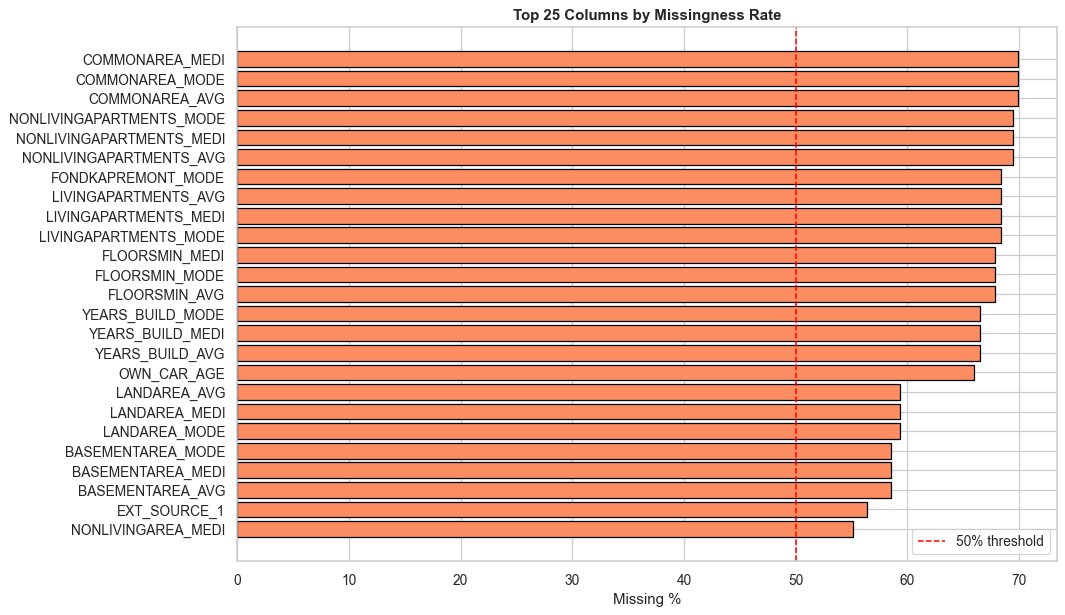

In [23]:
# Bar chart: top 25 columns by missingness rate
top_missing = missing_summary.head(25)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top_missing.index[::-1], top_missing['Missing_%'][::-1],
        color='#fc8d62', edgecolor='black')
ax.axvline(50, color='red', linestyle='--', linewidth=1.2, label='50% threshold')
ax.set_xlabel('Missing %')
ax.set_title('Top 25 Columns by Missingness Rate', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
# Missingness by TARGET: check if missingness differs between defaulters
default     = train[train['TARGET'] == 1]
non_default = train[train['TARGET'] == 0]

missing_compare = pd.DataFrame({
    'Missing_%_Default':    default.isna().mean() * 100,
    'Missing_%_NonDefault': non_default.isna().mean() * 100
})
missing_compare['Difference'] = (
    missing_compare['Missing_%_Default']
    - missing_compare['Missing_%_NonDefault']
)
missing_compare = missing_compare[
    missing_compare['Difference'].abs() > 0
].sort_values(by='Difference', key=abs, ascending=False)

print('Top 30 columns where missingness differs most between default vs non-default:')
print(missing_compare.head(30))

Top 30 columns where missingness differs most between default vs non-default:
                              Missing_%_Default  Missing_%_NonDefault  \
EMERGENCYSTATE_MODE                   54.372608             46.785833   
TOTALAREA_MODE                        55.210473             47.658887   
ENTRANCES_AVG                         57.244713             49.743178   
ENTRANCES_MEDI                        57.244713             49.743178   
ENTRANCES_MODE                        57.244713             49.743178   
FLOORSMAX_MODE                        56.652568             49.155600   
FLOORSMAX_MEDI                        56.652568             49.155600   
FLOORSMAX_AVG                         56.652568             49.155600   
YEARS_BEGINEXPLUATATION_AVG           55.621349             48.180313   
YEARS_BEGINEXPLUATATION_MEDI          55.621349             48.180313   
YEARS_BEGINEXPLUATATION_MODE          55.621349             48.180313   
APARTMENTS_MODE                       57.54280

In [25]:
#################################################################################
########################## Correlation with TARGET ##############################
#################################################################################

In [26]:
# Compute correlation of all numeric features with TARGET
corr_vals = {}
for c in numeric_features:
    s = train[c]
    if s.std() == 0 or s.isna().all():
        continue
    corr_vals[c] = s.corr(train['TARGET'])

corr = pd.Series(corr_vals).dropna()
top25 = corr.reindex(corr.abs().sort_values(ascending=False).index).head(25)

print('Top 25 features by |correlation with TARGET|:')
print(top25)

Top 25 features by |correlation with TARGET|:
EXT_SOURCE_3                  -0.178919
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_1                  -0.155317
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
DAYS_EMPLOYED                 -0.044932
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
FLOORSMAX_AVG                 -0.044003
FLOORSMAX_MEDI                -0.043768
FLOORSMAX_MODE                -0.043226
DAYS_REGISTRATION              0.041975
AMT_GOODS_PRICE               -0.039645
OWN_CAR_AGE                    0.037612
REGION_POPULATION_RELATIVE    -0.037227
ELEVATORS_AVG                 -0.034199
ELEVATORS_MEDI                -0.033863
FLOORSMIN_AVG                 -0.033614
FLOORSMIN_MEDI                -0.0

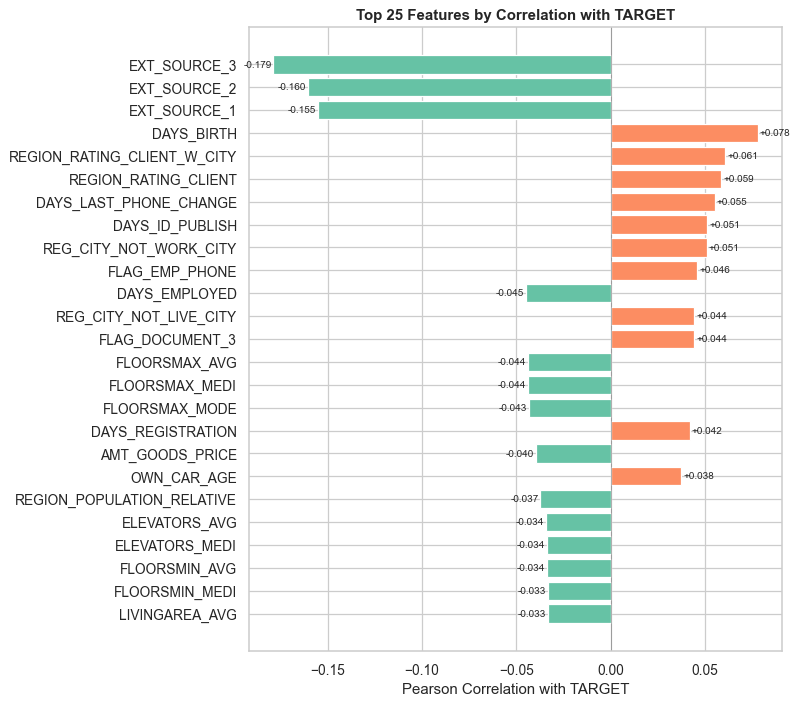

In [27]:
# Horizontal bar chart: Top 25 Features by Correlation with TARGET
fig, ax = plt.subplots(figsize=(9, 8))

colors = ['#fc8d62' if v > 0 else '#66c2a5' for v in top25]
ax.barh(top25.index[::-1], top25.values[::-1], color=colors[::-1])
ax.axvline(0, color='grey', lw=0.5)

# Label each bar with its value
for i, v in enumerate(top25.values[::-1]):
    ax.text(
        v + (0.001 if v >= 0 else -0.001), i,
        f'{v:+.3f}',
        va='center',
        ha='left' if v >= 0 else 'right',
        fontsize=8
    )

ax.set_xlabel('Pearson Correlation with TARGET')
ax.set_title('Top 25 Features by Correlation with TARGET', fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
#################################################################################
################################ EXT_SOURCE #####################################
#################################################################################

In [29]:
# EXT_SOURCE_1/2/3 are external credit scores and the strongest individual predictors of default in this dataset.
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

print('EXT_SOURCE descriptive stats by TARGET:')
print()
for col in ext_cols:
    nd = train[train['TARGET'] == 0][col]
    d  = train[train['TARGET'] == 1][col]
    print(f'{col}:')
    print(f'  Non-Default — mean: {nd.mean():.4f}  median: {nd.median():.4f}  missing: {nd.isna().mean()*100:.1f}%')
    print(f'  Default     — mean: {d.mean():.4f}  median: {d.median():.4f}  missing: {d.isna().mean()*100:.1f}%')
    print()

EXT_SOURCE descriptive stats by TARGET:

EXT_SOURCE_1:
  Non-Default — mean: 0.5115  median: 0.5175  missing: 56.1%
  Default     — mean: 0.3870  median: 0.3617  missing: 59.5%

EXT_SOURCE_2:
  Non-Default — mean: 0.5235  median: 0.5739  missing: 0.2%
  Default     — mean: 0.4109  median: 0.4404  missing: 0.2%

EXT_SOURCE_3:
  Non-Default — mean: 0.5210  median: 0.5460  missing: 19.6%
  Default     — mean: 0.3907  median: 0.3791  missing: 22.9%



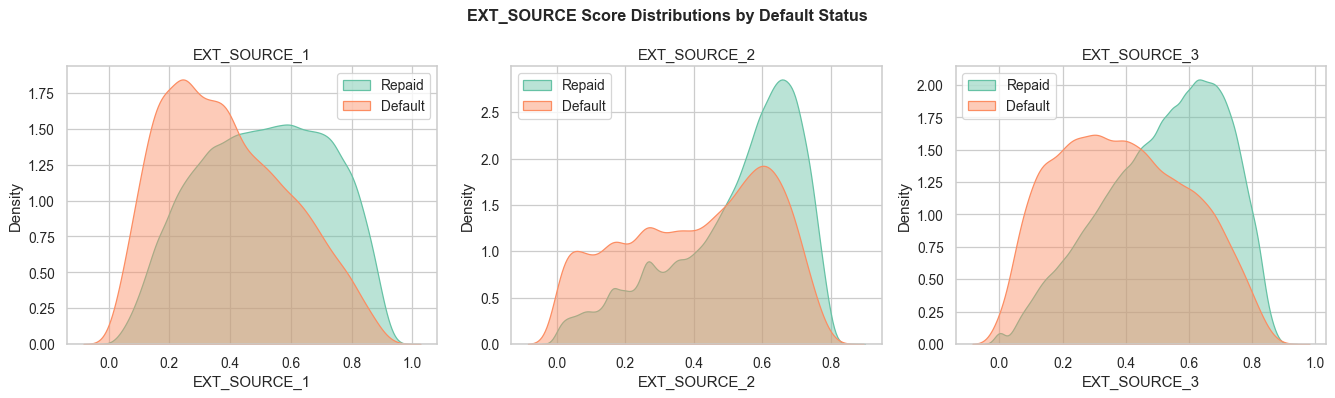

In [30]:
# KDE plots: EXT_SOURCE distributions by class
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, col in zip(axes, ext_cols):
    for tval, color, lbl in [(0, '#66c2a5', 'Repaid'), (1, '#fc8d62', 'Default')]:
        sns.kdeplot(
            train[train['TARGET'] == tval][col].dropna(),
            ax=ax, fill=True, alpha=0.45,
            label=lbl, color=color
        )
    ax.set_title(f'{col}')
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle('EXT_SOURCE Score Distributions by Default Status',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# EXT_SOURCE correlation with TARGET
print('Correlation with TARGET:')
print(train[ext_cols + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values())

Correlation with TARGET:
EXT_SOURCE_3   -0.178919
EXT_SOURCE_2   -0.160472
EXT_SOURCE_1   -0.155317
Name: TARGET, dtype: float64


In [32]:
#################################################################################
########################## Continuous Features Summary ##########################
#################################################################################

In [33]:
# For each continuous feature, compare median and mean between default and non-default groups, and note missingness rate.
continuous_summary = pd.DataFrame()

for col in continuous_numeric_cols:
    nd = train[train['TARGET'] == 0][col]
    d  = train[train['TARGET'] == 1][col]

    continuous_summary.loc[col, 'Non_Default_Median'] = nd.median()
    continuous_summary.loc[col, 'Default_Median']     = d.median()
    continuous_summary.loc[col, 'Non_Default_Mean']   = nd.mean()
    continuous_summary.loc[col, 'Default_Mean']       = d.mean()
    continuous_summary.loc[col, 'Missing_%']          = train[col].isna().mean() * 100
    continuous_summary.loc[col, 'Median_Difference']  = d.median() - nd.median()

continuous_summary = continuous_summary.sort_values(
    by='Median_Difference', key=abs, ascending=False
)

print('Continuous feature summary (sorted by |median difference|):')
print(continuous_summary)

Continuous feature summary (sorted by |median difference|):
                              Non_Default_Median  Default_Median  \
AMT_CREDIT                         517788.000000   497520.000000   
AMT_INCOME_TOTAL                   148500.000000   135000.000000   
DAYS_BIRTH                         -15877.000000   -14282.000000   
DAYS_ID_PUBLISH                     -3295.000000    -2797.000000   
DAYS_REGISTRATION                   -4544.000000    -4056.000000   
AMT_ANNUITY                         24876.000000    25263.000000   
DAYS_EMPLOYED                       -1235.000000    -1034.000000   
DAYS_LAST_PHONE_CHANGE               -776.000000     -594.000000   
OWN_CAR_AGE                             9.000000       11.000000   
AMT_REQ_CREDIT_BUREAU_YEAR              1.000000        2.000000   
EXT_SOURCE_3                            0.546023        0.379100   
EXT_SOURCE_1                            0.517452        0.361675   
EXT_SOURCE_2                            0.573905        

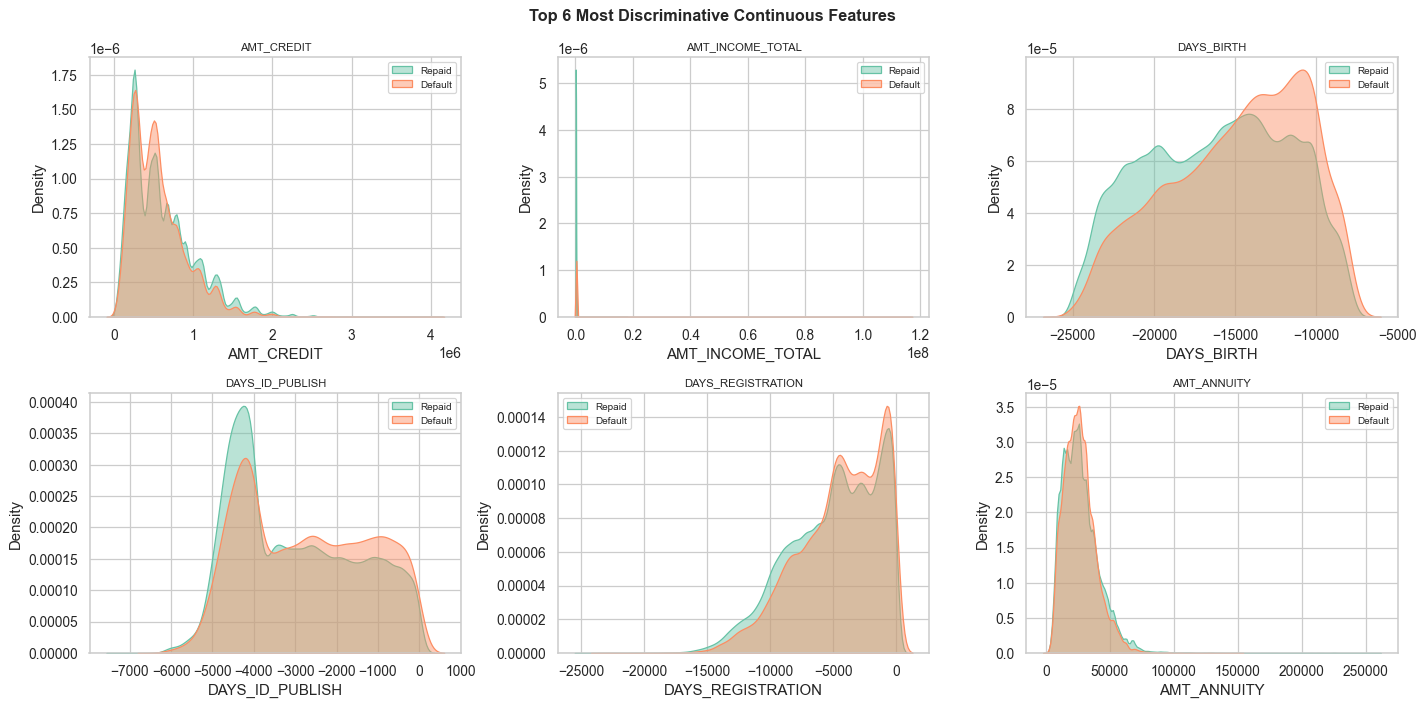

In [34]:
# KDE plots: top 6 most discriminative continuous features
top6 = continuous_summary.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(top6):
    nd = train[train['TARGET'] == 0][col].dropna()
    d  = train[train['TARGET'] == 1][col].dropna()

    sns.kdeplot(nd, ax=axes[i], fill=True, alpha=0.45,
                label='Repaid', color='#66c2a5')
    sns.kdeplot(d,  ax=axes[i], fill=True, alpha=0.45,
                label='Default', color='#fc8d62')
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=8)

plt.suptitle('Top 6 Most Discriminative Continuous Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

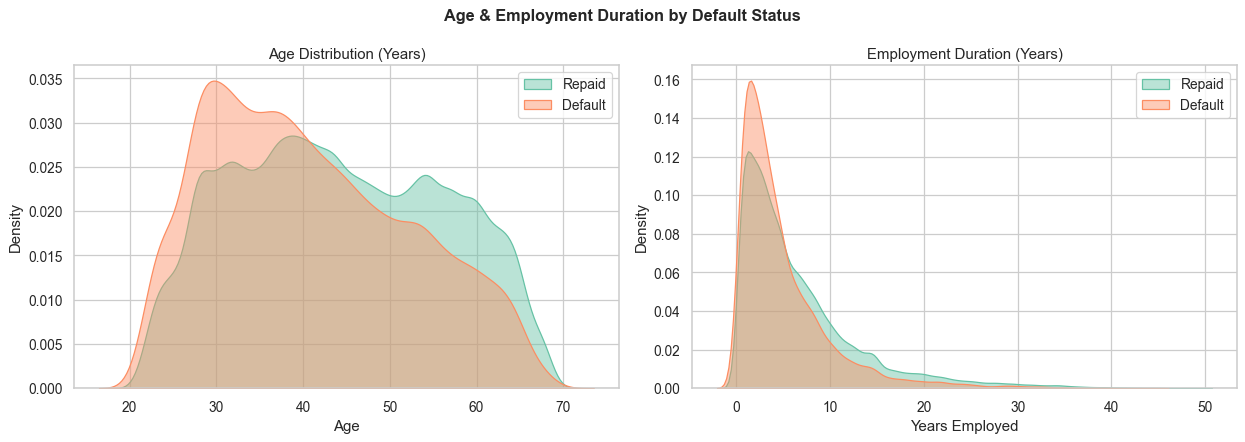

In [35]:
# Age and employment stability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for tval, label, color in [(0, 'Repaid', '#66c2a5'), (1, 'Default', '#fc8d62')]:
    subset = train[train['TARGET'] == tval]

    # Age in years
    age = -subset['DAYS_BIRTH'] / 365
    sns.kdeplot(age, ax=axes[0], fill=True, alpha=0.45,
                label=label, color=color)

    # Employment years (exclude anomalous 365243 values)
    emp = subset[subset['DAYS_EMPLOYED'] != 365243]
    emp_years = -emp['DAYS_EMPLOYED'] / 365
    sns.kdeplot(emp_years, ax=axes[1], fill=True, alpha=0.45,
                label=label, color=color)

axes[0].set_title('Age Distribution (Years)')
axes[0].set_xlabel('Age')
axes[0].legend()

axes[1].set_title('Employment Duration (Years)')
axes[1].set_xlabel('Years Employed')
axes[1].legend()

plt.suptitle('Age & Employment Duration by Default Status',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

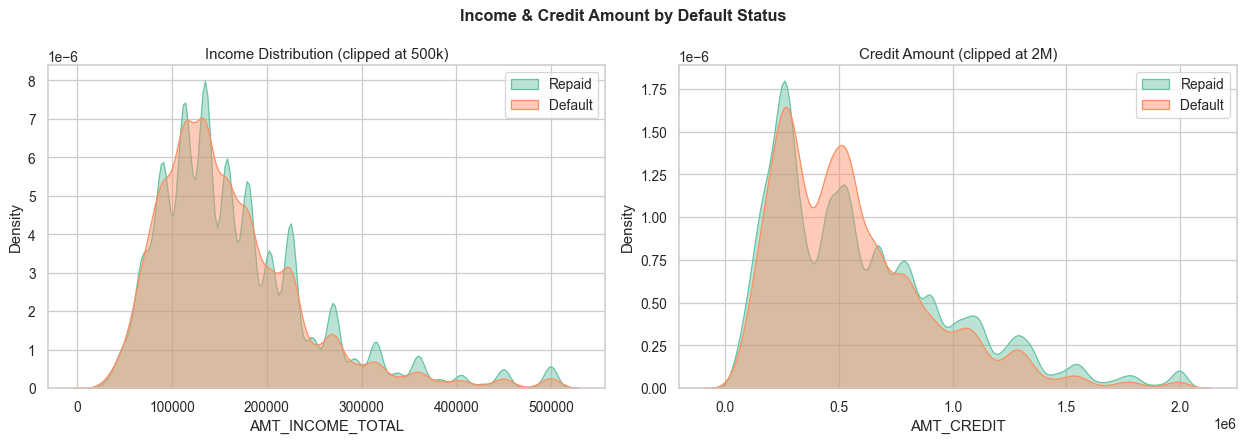

In [36]:
# Income and credit amount
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for tval, label, color in [(0, 'Repaid', '#66c2a5'), (1, 'Default', '#fc8d62')]:
    subset = train[train['TARGET'] == tval]

    sns.kdeplot(subset['AMT_INCOME_TOTAL'].clip(upper=500_000),
                ax=axes[0], fill=True, alpha=0.45,
                label=label, color=color)

    sns.kdeplot(subset['AMT_CREDIT'].clip(upper=2_000_000),
                ax=axes[1], fill=True, alpha=0.45,
                label=label, color=color)

axes[0].set_title('Income Distribution (clipped at 500k)')
axes[0].set_xlabel('AMT_INCOME_TOTAL')
axes[0].legend()

axes[1].set_title('Credit Amount (clipped at 2M)')
axes[1].set_xlabel('AMT_CREDIT')
axes[1].legend()

plt.suptitle('Income & Credit Amount by Default Status',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
# Income and credit amount: Outliers

# Outlier analysis table
def iqr_threshold(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q3 + 1.5 * IQR

income_threshold = iqr_threshold(train['AMT_INCOME_TOTAL'])
credit_threshold = iqr_threshold(train['AMT_CREDIT'])

results = []

for col, threshold in [('AMT_INCOME_TOTAL', income_threshold),
                       ('AMT_CREDIT',       credit_threshold)]:
    outliers     = train[train[col] > threshold]
    non_outliers = train[train[col] <= threshold]

    results.append({
        'Feature':                col,
        'Threshold':              f'{threshold:,.0f}',
        'Total_Outliers':         len(outliers),
        'Outlier_%_of_Dataset':   f'{len(outliers)/len(train)*100:.1f}%',
        'Default_Rate_Outliers':  f'{outliers["TARGET"].mean()*100:.1f}%',
        'Default_Rate_NonOutliers': f'{non_outliers["TARGET"].mean()*100:.1f}%',
        'Overall_Default_Rate':   f'{train["TARGET"].mean()*100:.1f}%'
    })

outlier_table = pd.DataFrame(results).set_index('Feature')
print(outlier_table.T)

Feature                  AMT_INCOME_TOTAL AMT_CREDIT
Threshold                         337,500  1,616,625
Total_Outliers                      14035       6562
Outlier_%_of_Dataset                 4.6%       2.1%
Default_Rate_Outliers                5.8%       4.1%
Default_Rate_NonOutliers             8.2%       8.2%
Overall_Default_Rate                 8.1%       8.1%


In [38]:
#################################################################################
############################# Binary Numeric Features ###########################
#################################################################################

In [39]:
# For each binary flag, show the default rate when flag=0 vs flag=1.
# This tells us which flags are associated with higher default risk.

binary_results = []

for col in binary_numeric_cols:
    temp = (
        pd.crosstab(train[col], train['TARGET'], normalize='index') * 100
    )
    if 1 in temp.columns and 0 in temp.columns:
        binary_results.append({
            'Feature':          col,
            'Default_%_when_0': round(temp.loc[0, 1], 2) if 0 in temp.index else None,
            'Default_%_when_1': round(temp.loc[1, 1], 2) if 1 in temp.index else None,
        })

binary_df = pd.DataFrame(binary_results)
binary_df['Lift'] = binary_df['Default_%_when_1'] - binary_df['Default_%_when_0']
binary_df = binary_df.sort_values('Lift', key=abs, ascending=False)

print('Binary features ranked by default rate lift (flag=1 vs flag=0):')
print(binary_df.to_string(index=False))

Binary features ranked by default rate lift (flag=1 vs flag=0):
                    Feature  Default_%_when_0  Default_%_when_1  Lift
            FLAG_DOCUMENT_2              8.07             30.77 22.70
                 FLAG_MOBIL              0.00              8.07  8.07
            FLAG_DOCUMENT_4              8.07              0.00 -8.07
           FLAG_DOCUMENT_12              8.07              0.00 -8.07
           FLAG_DOCUMENT_10              8.07              0.00 -8.07
           FLAG_DOCUMENT_17              8.07              2.44 -5.63
           FLAG_DOCUMENT_21              8.07             13.59  5.52
           FLAG_DOCUMENT_13              8.09              2.77 -5.32
           FLAG_DOCUMENT_15              8.08              2.96 -5.12
           FLAG_DOCUMENT_14              8.09              3.32 -4.77
     REG_CITY_NOT_LIVE_CITY              7.72             12.23  4.51
     REG_CITY_NOT_WORK_CITY              7.31             10.61  3.30
             FLAG_EMP_PHON

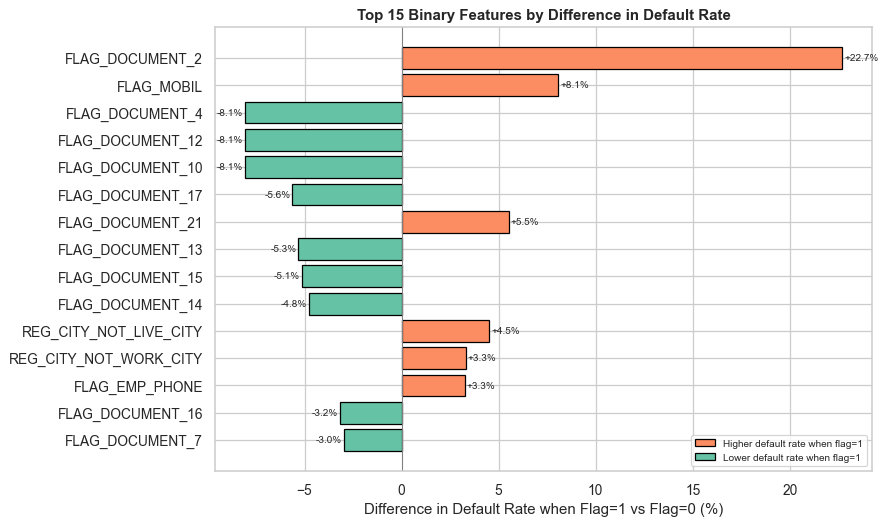

In [40]:
# Bar chart: top 15 binary features by default rate difference

top_binary = binary_df.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#fc8d62' if v > 0 else '#66c2a5' for v in top_binary['Lift']]
ax.barh(top_binary['Feature'][::-1], top_binary['Lift'][::-1],
        color=colors[::-1], edgecolor='black')
ax.axvline(0, color='grey', lw=0.8)

# Label each bar with its value
for i, v in enumerate(top_binary['Lift'][::-1]):
    ax.text(
        v + (0.1 if v >= 0 else -0.1), i,
        f'{v:+.1f}%',
        va='center',
        ha='left' if v >= 0 else 'right',
        fontsize=8
    )

ax.set_xlabel('Difference in Default Rate when Flag=1 vs Flag=0 (%)')
ax.set_title('Top 15 Binary Features by Difference in Default Rate',
             fontweight='bold')

# Add a legend to explain colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#fc8d62', edgecolor='black', label='Higher default rate when flag=1'),
    Patch(facecolor='#66c2a5', edgecolor='black', label='Lower default rate when flag=1')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

In [41]:
# Detailed crosstab for each binary feature
for col in binary_numeric_cols:
    print('\n' + '='*60)
    print(col)
    temp = (
        pd.crosstab(train[col], train['TARGET'], normalize='index') * 100
    )
    temp.columns = ['Non_Default_%', 'Default_%']
    print(temp)


FLAG_MOBIL
            Non_Default_%  Default_%
FLAG_MOBIL                          
0              100.000000   0.000000
1               91.927092   8.072908

FLAG_EMP_PHONE
                Non_Default_%  Default_%
FLAG_EMP_PHONE                          
0                   94.599718   5.400282
1                   91.340010   8.659990

FLAG_WORK_PHONE
                 Non_Default_%  Default_%
FLAG_WORK_PHONE                          
0                    92.314878   7.685122
1                    90.369935   9.630065

FLAG_CONT_MOBILE
                  Non_Default_%  Default_%
FLAG_CONT_MOBILE                          
0                     92.160279   7.839721
1                     91.926682   8.073318

FLAG_PHONE
            Non_Default_%  Default_%
FLAG_PHONE                          
0               91.521621   8.478379
1               92.964330   7.035670

FLAG_EMAIL
            Non_Default_%  Default_%
FLAG_EMAIL                          
0               91.915372   8.084628
1 

In [42]:
# For each categorical feature, show the default rate per category,
# sorted from highest to lowest default rate.

for col in cat_cols:
    print('\n' + '='*70)
    print(col)
    temp = (
        pd.crosstab(train[col], train['TARGET'], normalize='index') * 100
    )
    temp.columns = ['Non_Default_%', 'Default_%']
    print(temp.sort_values('Default_%', ascending=False))


NAME_CONTRACT_TYPE
                    Non_Default_%  Default_%
NAME_CONTRACT_TYPE                          
Cash loans              91.654087   8.345913
Revolving loans         94.521671   5.478329

CODE_GENDER
             Non_Default_%  Default_%
CODE_GENDER                          
M                89.858080  10.141920
F                93.000672   6.999328
XNA             100.000000   0.000000

FLAG_OWN_CAR
              Non_Default_%  Default_%
FLAG_OWN_CAR                          
N                 91.499773   8.500227
Y                 92.756270   7.243730

FLAG_OWN_REALTY
                 Non_Default_%  Default_%
FLAG_OWN_REALTY                          
N                    91.675071   8.324929
Y                    92.038423   7.961577

NAME_TYPE_SUITE
                 Non_Default_%  Default_%
NAME_TYPE_SUITE                          
Other_B              90.169492   9.830508
Other_A              91.224018   8.775982
Group of people      91.512915   8.487085
Unaccompanied  

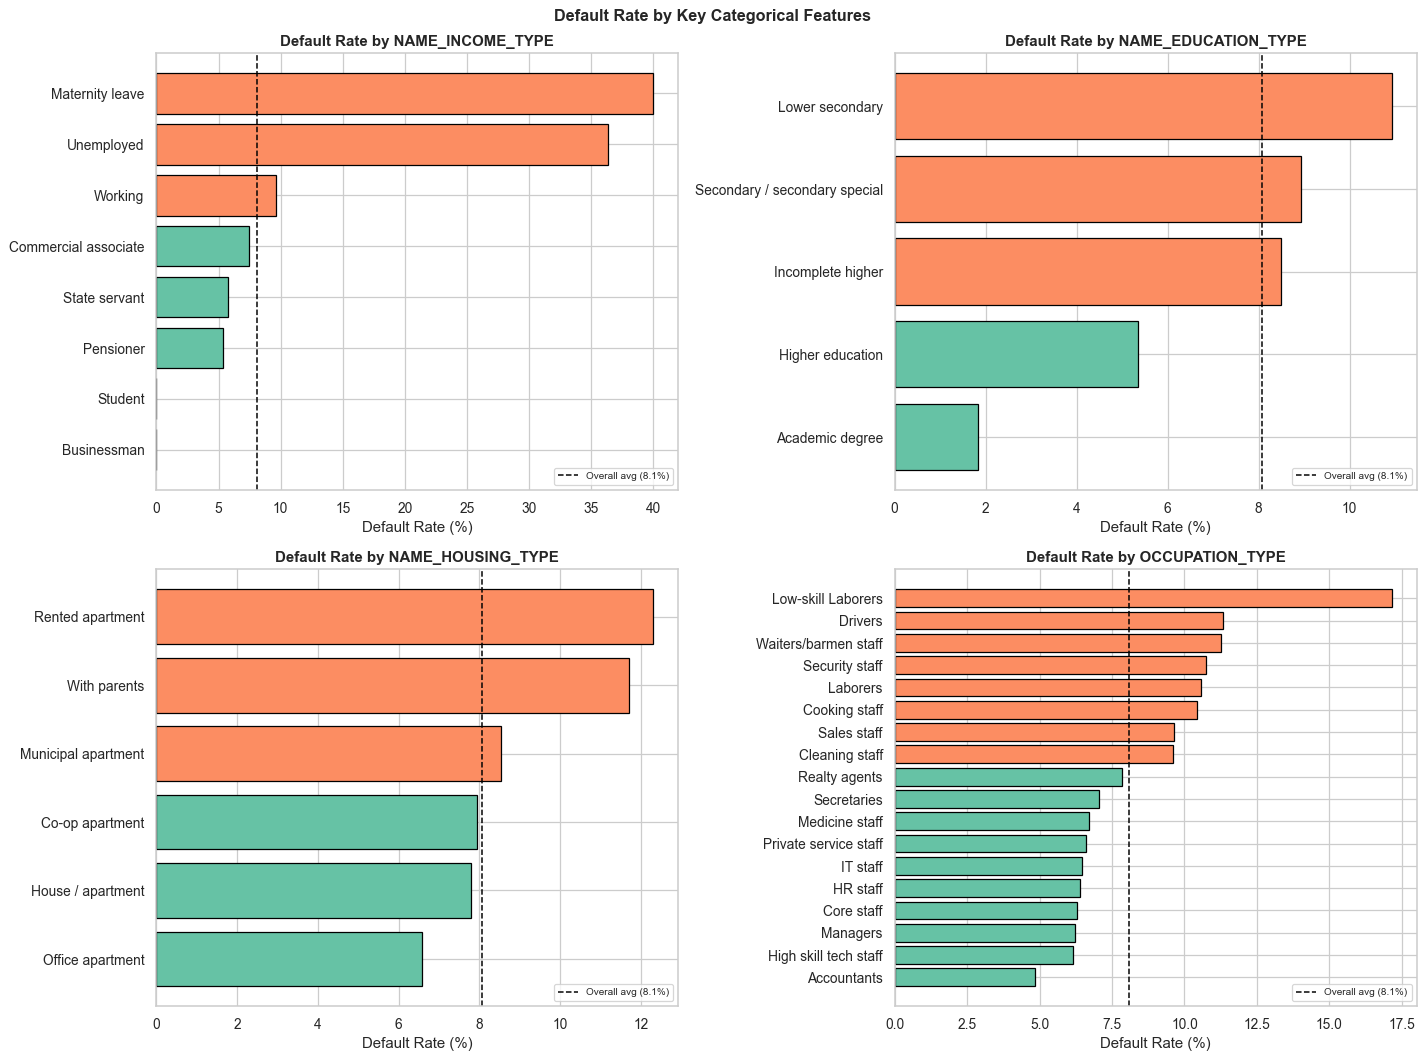

In [43]:
# Bar charts: default rate for 4 key categorical features
key_cats = ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
            'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

overall_default_rate = train['TARGET'].mean() * 100

for i, col in enumerate(key_cats):
    rates = (
        train.groupby(col)['TARGET'].mean() * 100
    ).sort_values(ascending=True)

    colors = ['#fc8d62' if r > overall_default_rate else '#66c2a5'
              for r in rates.values]

    axes[i].barh(rates.index, rates.values,
                 color=colors, edgecolor='black')
    axes[i].axvline(overall_default_rate, color='black',
                    linestyle='--', linewidth=1.2,
                    label=f'Overall avg ({overall_default_rate:.1f}%)')
    axes[i].set_title(f'Default Rate by {col}', fontweight='bold')
    axes[i].set_xlabel('Default Rate (%)')
    axes[i].legend(fontsize=8)

plt.suptitle('Default Rate by Key Categorical Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

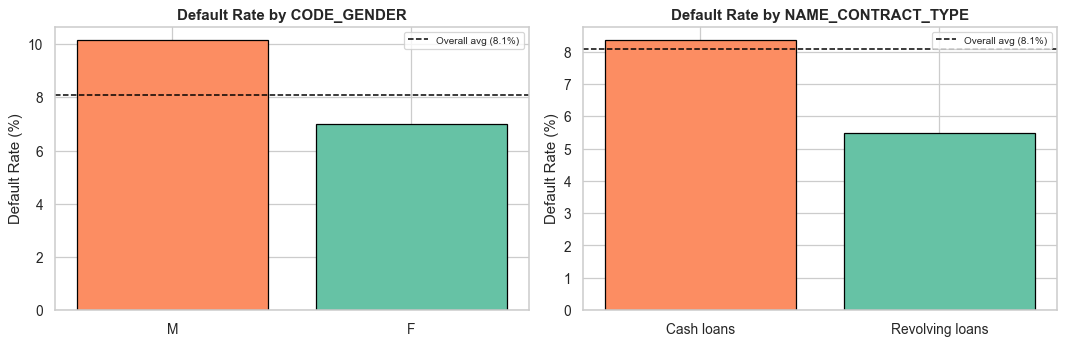

In [44]:
# Gender and contract type
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(['CODE_GENDER', 'NAME_CONTRACT_TYPE']):
    rates = (
        train[train[col] != 'XNA']
        .groupby(col)['TARGET'].mean() * 100
    ).sort_values(ascending=False)

    axes[i].bar(rates.index, rates.values,
                color=['#fc8d62', '#66c2a5', '#8da0cb'][:len(rates)],
                edgecolor='black')
    axes[i].axhline(overall_default_rate, color='black',
                    linestyle='--', linewidth=1.2,
                    label=f'Overall avg ({overall_default_rate:.1f}%)')
    axes[i].set_title(f'Default Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

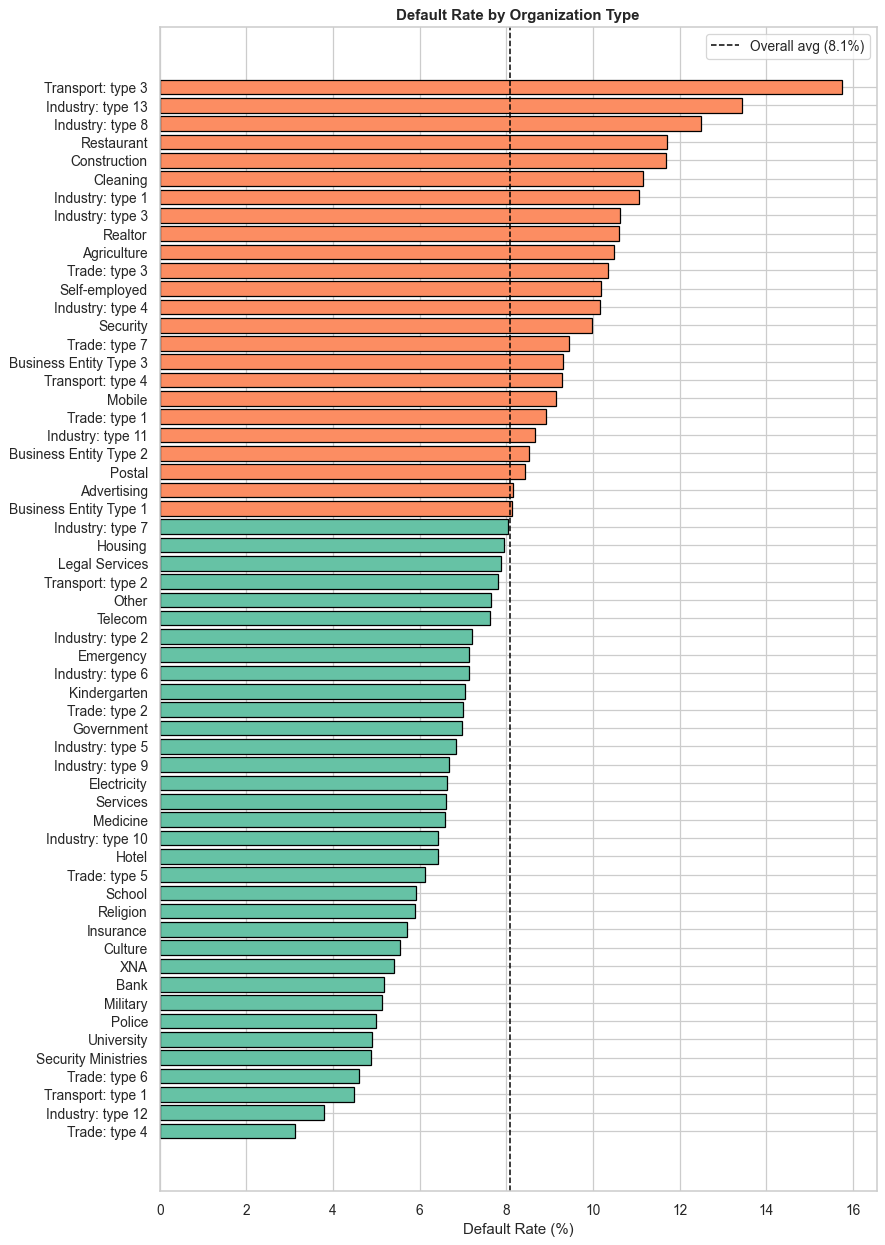

In [45]:
# Organization type
org_rates = (
    train.groupby('ORGANIZATION_TYPE')['TARGET'].mean() * 100
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
colors = ['#fc8d62' if r > overall_default_rate else '#66c2a5'
          for r in org_rates.values]
ax.barh(org_rates.index, org_rates.values,
        color=colors, edgecolor='black')
ax.axvline(overall_default_rate, color='black',
           linestyle='--', linewidth=1.2,
           label=f'Overall avg ({overall_default_rate:.1f}%)')
ax.set_xlabel('Default Rate (%)')
ax.set_title('Default Rate by Organization Type', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## Data Cleaning & Merging
> Raw data was cleaned by correcting erroneous values, handling missing data, and engineering new features before merging all datasets into a single dataset.


In [46]:
#################################################################################
################################# Import libraries ##############################
#################################################################################

In [47]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
#################################################################################
################################### Load Datasets ###############################
#################################################################################

In [ ]:
# # Main
# train = pd.read_csv("/content/drive/MyDrive/Project#24/data-kaggle/home-credit-default-risk/application_train.csv")
# test = pd.read_csv("/content/drive/MyDrive/Project#24/data-kaggle/home-credit-default-risk/application_test.csv")

# # External credit
# bureau = pd.read_csv("/content/drive/MyDrive/Project#24/data-kaggle/home-credit-default-risk/bureau.csv")
# bureau_balance = pd.read_csv("/content/drive/MyDrive/Project#24/data-kaggle/home-credit-default-risk/bureau_balance.csv")

# # Home Credit history
# previous_application = pd.read_csv("/content/drive/MyDrive/Project#24/data-kaggle/home-credit-default-risk/previous_application.csv")
# POS_CASH_balance = pd.read_csv("/content/drive/MyDrive/Project#24/data-kaggle/home-credit-default-risk/POS_CASH_balance.csv")
# credit_card_balance = pd.read_csv("/content/drive/MyDrive/Project#24/data-kaggle/home-credit-default-risk/credit_card_balance.csv")
# installments_payments = pd.read_csv("/content/drive/MyDrive/Project#24/data-kaggle/home-credit-default-risk/installments_payments.csv")


# Main
train = pd.read_csv("C:/Users/richardsm/AI-Projects/llm/home-credit-default-risk/home-credit-default-risk/application_train.csv")
test = pd.read_csv("C:/Users/richardsm/AI-Projects/llm/home-credit-default-risk/home-credit-default-risk/application_test.csv")

# External credit
bureau = pd.read_csv("C:/Users/richardsm/AI-Projects/llm/home-credit-default-risk/home-credit-default-risk/bureau.csv")
bureau_balance = pd.read_csv("C:/Users/richardsm/AI-Projects/llm/home-credit-default-risk/home-credit-default-risk/bureau_balance.csv")

# Home Credit history
previous_application = pd.read_csv("C:/Users/richardsm/AI-Projects/llm/home-credit-default-risk/home-credit-default-risk/previous_application.csv")
POS_CASH_balance = pd.read_csv("C:/Users/richardsm/AI-Projects/llm/home-credit-default-risk/home-credit-default-risk/POS_CASH_balance.csv")
credit_card_balance = pd.read_csv("C:/Users/richardsm/AI-Projects/llm/home-credit-default-risk/home-credit-default-risk/credit_card_balance.csv")
installments_payments = pd.read_csv("C:/Users/richardsm/AI-Projects/llm/home-credit-default-risk/home-credit-default-risk/installments_payments.csv")

print("Train:",          train.shape)
print("Test:",           test.shape)
print("Bureau:",         bureau.shape)
print("Bureau Balance:", bureau_balance.shape)
print("Previous App:",   previous_application.shape)
print("POS Cash:",       POS_CASH_balance.shape)
print("Credit Card:",    credit_card_balance.shape)
print("Installments:",   installments_payments.shape)

Train: (307511, 122)
Test: (48744, 121)
Bureau: (1716428, 17)
Bureau Balance: (27299925, 3)
Previous App: (1670214, 37)
POS Cash: (10001358, 8)
Credit Card: (3840312, 23)
Installments: (13605401, 8)


In [50]:
# Remove erroneous gender code
train = train[train["CODE_GENDER"] != "XNA"]

# Clip income outlier
train["AMT_INCOME_TOTAL"] = train["AMT_INCOME_TOTAL"].clip(upper=20_000_000)
test["AMT_INCOME_TOTAL"]  = test["AMT_INCOME_TOTAL"].clip(upper=20_000_000)

# DAYS_EMPLOYED erroneous  value
train["DAYS_EMPLOYED_MISSING"] = (train["DAYS_EMPLOYED"] == 365243).astype(int)
test["DAYS_EMPLOYED_MISSING"]  = (test["DAYS_EMPLOYED"] == 365243).astype(int)
train["DAYS_EMPLOYED"] = train["DAYS_EMPLOYED"].replace(365243, np.nan)
test["DAYS_EMPLOYED"]  = test["DAYS_EMPLOYED"].replace(365243, np.nan)

# DAYS_LAST_PHONE_CHANGE erroneous  value
train["DAYS_LAST_PHONE_CHANGE"] = train["DAYS_LAST_PHONE_CHANGE"].replace(0, np.nan)
test["DAYS_LAST_PHONE_CHANGE"]  = test["DAYS_LAST_PHONE_CHANGE"].replace(0, np.nan)

# Missingness flags with predictive signal
train["FLAG_MISSING_EXT_SOURCE_1"] = train["EXT_SOURCE_1"].isna().astype(int)
test["FLAG_MISSING_EXT_SOURCE_1"]  = test["EXT_SOURCE_1"].isna().astype(int)

train["FLAG_MISSING_EXT_SOURCE_2"] = train["EXT_SOURCE_2"].isna().astype(int)
test["FLAG_MISSING_EXT_SOURCE_2"]  = test["EXT_SOURCE_2"].isna().astype(int)

train["FLAG_MISSING_EXT_SOURCE_3"] = train["EXT_SOURCE_3"].isna().astype(int)
test["FLAG_MISSING_EXT_SOURCE_3"]  = test["EXT_SOURCE_3"].isna().astype(int)

train["FLAG_MISSING_OWN_CAR_AGE"] = train["OWN_CAR_AGE"].isna().astype(int)
test["FLAG_MISSING_OWN_CAR_AGE"]  = test["OWN_CAR_AGE"].isna().astype(int)

# Count-like variables: missing interpreted as no recorded event
zero_impute_cols = [
    "AMT_REQ_CREDIT_BUREAU_HOUR", "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK", "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",  "AMT_REQ_CREDIT_BUREAU_YEAR",
    "OBS_30_CNT_SOCIAL_CIRCLE",   "DEF_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE",   "DEF_60_CNT_SOCIAL_CIRCLE",
]
train[zero_impute_cols] = train[zero_impute_cols].fillna(0)
test[zero_impute_cols]  = test[zero_impute_cols].fillna(0)

# Categorical missingness preserved as explicit category = "Unkown"
cat_fill_cols = [
    "FONDKAPREMONT_MODE", "WALLSMATERIAL_MODE", "HOUSETYPE_MODE",
    "EMERGENCYSTATE_MODE", "OCCUPATION_TYPE", "NAME_TYPE_SUITE"
]

train[cat_fill_cols] = train[cat_fill_cols].fillna("Unknown")
test[cat_fill_cols]  = test[cat_fill_cols].fillna("Unknown")

# Document flag aggregates
docs = [f for f in train.columns if "FLAG_DOC" in f]
train["DOCUMENT_COUNT"] = train[docs].sum(axis=1)
train["NEW_DOC_KURT"]   = train[docs].kurtosis(axis=1)
test["DOCUMENT_COUNT"]  = test[docs].sum(axis=1)
test["NEW_DOC_KURT"]    = test[docs].kurtosis(axis=1)

# Age bucket for groupby peer features
def get_age_label(days_birth):
    age = -days_birth / 365
    if age < 27: return 1
    elif age < 40: return 2
    elif age < 50: return 3
    elif age < 65: return 4
    elif age < 99: return 5
    else: return 0

train["AGE_RANGE"] = train["DAYS_BIRTH"].apply(get_age_label)
test["AGE_RANGE"]  = test["DAYS_BIRTH"].apply(get_age_label)

print("Train:", train.shape)
print("Test:",  test.shape)

Train: (307507, 130)
Test: (48744, 129)


In [51]:
#################################################################################
################################### Merge Main Datasets #########################
#################################################################################

In [52]:
train["is_train"] = 1
test["is_train"]  = 0
test["TARGET"]    = np.nan

df_main = pd.concat([train, test], axis=0).reset_index(drop=True)

print("df_main shape:", df_main.shape)
print("is_train counts:\n", df_main["is_train"].value_counts())
print("TARGET missing:", df_main["TARGET"].isna().sum())

df_main shape: (356251, 131)
is_train counts:
 is_train
1    307507
0     48744
Name: count, dtype: int64
TARGET missing: 48744


In [53]:
#################################################################################
############################## APPLICATION FEATURES #############################
#################################################################################

In [54]:
print(train[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "TARGET"]].corr()["TARGET"].sort_values())

EXT_SOURCE_3   -0.178926
EXT_SOURCE_2   -0.160471
EXT_SOURCE_1   -0.155317
TARGET          1.000000
Name: TARGET, dtype: float64


In [55]:
# EXT_SOURCE aggregates
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
df_main["EXT_SOURCE_MEAN"]          = df_main[ext_cols].mean(axis=1)
df_main["EXT_SOURCE_STD"]           = df_main[ext_cols].std(axis=1)
df_main["EXT_SOURCE_MIN"]           = df_main[ext_cols].min(axis=1)
df_main["EXT_SOURCE_MAX"]           = df_main[ext_cols].max(axis=1)
df_main["EXT_SOURCE_NANMEDIAN"]     = df_main[ext_cols].median(axis=1)
df_main["EXT_SOURCE_VAR"]           = df_main[ext_cols].var(axis=1)
df_main["EXT_SOURCE_NANSUM"]        = df_main[ext_cols].sum(axis=1)
df_main["EXT_SOURCE_MISSING_COUNT"] = df_main[ext_cols].isnull().sum(axis=1)
# NEW: spread between highest and lowest score — captures disagreement
df_main["EXT_SOURCE_RANGE"]         = df_main[ext_cols].max(axis=1) - df_main[ext_cols].min(axis=1)

# EXT_SOURCE interaction terms
df_main["EXT_SOURCE_PROD"] = df_main["EXT_SOURCE_1"] * df_main["EXT_SOURCE_2"] * df_main["EXT_SOURCE_3"]
df_main["EXT_SOURCE_2_3"]  = df_main["EXT_SOURCE_2"] * df_main["EXT_SOURCE_3"]
df_main["EXT_SOURCE_1_2"]  = df_main["EXT_SOURCE_1"] * df_main["EXT_SOURCE_2"]
df_main["EXT_SOURCE_1_3"]  = df_main["EXT_SOURCE_1"] * df_main["EXT_SOURCE_3"]

# Weights proportional to correlation strength (EXT_SOURCE_3 most predictive)
df_main["EXT_SOURCE_WEIGHTED"] = (
    df_main["EXT_SOURCE_1"] * 1 +
    df_main["EXT_SOURCE_2"] * 2 +
    df_main["EXT_SOURCE_3"] * 3
)

#  Credit and income ratios
df_main["CREDIT_TO_ANNUITY_RATIO"] = df_main["AMT_CREDIT"]  / df_main["AMT_ANNUITY"]
df_main["CREDIT_TO_INCOME_RATIO"]  = df_main["AMT_CREDIT"]  / df_main["AMT_INCOME_TOTAL"]
df_main["CREDIT_TO_GOODS_RATIO"]   = df_main["AMT_CREDIT"]  / df_main["AMT_GOODS_PRICE"]
df_main["ANNUITY_TO_INCOME_RATIO"] = df_main["AMT_ANNUITY"] / df_main["AMT_INCOME_TOTAL"]
df_main["ANNUITY_CREDIT_RATIO"]    = df_main["AMT_ANNUITY"] / df_main["AMT_CREDIT"]
df_main["INCOME_PER_PERSON"]       = df_main["AMT_INCOME_TOTAL"] / df_main["CNT_FAM_MEMBERS"]
df_main["CHILDREN_RATIO"]          = df_main["CNT_CHILDREN"]     / df_main["CNT_FAM_MEMBERS"]
df_main["PAYMENT_RATE"]            = df_main["AMT_ANNUITY"]      / df_main["AMT_CREDIT"]
df_main["INCOME_TO_EMPLOYED_RATIO"]= df_main["AMT_INCOME_TOTAL"] / df_main["DAYS_EMPLOYED"]
df_main["INCOME_TO_BIRTH_RATIO"]   = df_main["AMT_INCOME_TOTAL"] / df_main["DAYS_BIRTH"]
# NEW: down payment proxy — negative means credit exceeds goods price
df_main["DOWN_PAYMENT"]            = df_main["AMT_GOODS_PRICE"] - df_main["AMT_CREDIT"]
df_main["DOWN_PAYMENT_RATIO"]      = df_main["DOWN_PAYMENT"] / (df_main["AMT_GOODS_PRICE"] + 1)
# NEW: credit hunger — high income vs few enquiries is a positive signal
df_main["INCOME_TO_CREDIT_ENQUIRIES"] = df_main["AMT_INCOME_TOTAL"] / (df_main["AMT_REQ_CREDIT_BUREAU_YEAR"] + 1)

#  Time ratios
df_main["DAYS_EMPLOYED_PERCENT"] = df_main["DAYS_EMPLOYED"]          / df_main["DAYS_BIRTH"]
df_main["ID_TO_BIRTH_RATIO"]     = df_main["DAYS_ID_PUBLISH"]        / df_main["DAYS_BIRTH"]
df_main["CAR_TO_BIRTH_RATIO"]    = df_main["OWN_CAR_AGE"]            / df_main["DAYS_BIRTH"]
df_main["CAR_TO_EMPLOYED_RATIO"] = df_main["OWN_CAR_AGE"]            / df_main["DAYS_EMPLOYED"]
df_main["PHONE_TO_BIRTH_RATIO"]  = df_main["DAYS_LAST_PHONE_CHANGE"] / df_main["DAYS_BIRTH"]

# readable age and employment years
df_main["AGE_YEARS"]             = -df_main["DAYS_BIRTH"] / 365
df_main["EMPLOYMENT_YEARS"]      = df_main["DAYS_EMPLOYED"].clip(upper=0) / 365

#  age when client started current job
df_main["AGE_AT_EMPLOYMENT_START"]  = df_main["AGE_YEARS"] + df_main["EMPLOYMENT_YEARS"]

# document stability proxy
df_main["REGISTRATION_YEARS"]       = -df_main["DAYS_REGISTRATION"] / 365
df_main["ID_PUBLISH_YEARS"]         = -df_main["DAYS_ID_PUBLISH"]   / 365
df_main["ID_TO_REGISTRATION_RATIO"] = df_main["ID_PUBLISH_YEARS"] / (df_main["REGISTRATION_YEARS"] + 1)

# binary life-stage flags
df_main["IS_NEAR_RETIREMENT"] = (df_main["AGE_YEARS"] >= 55).astype(int)
df_main["IS_YOUNG_BORROWER"]  = (df_main["AGE_YEARS"] <  30).astype(int)

# Groupby peer features
group_cols = ["ORGANIZATION_TYPE", "NAME_EDUCATION_TYPE", "OCCUPATION_TYPE", "AGE_RANGE", "CODE_GENDER"]
df_main["GROUP_EXT_SOURCES_MEDIAN"]     = df_main.groupby(group_cols)["EXT_SOURCE_MEAN"].transform("median")
df_main["GROUP_EXT_SOURCES_STD"]        = df_main.groupby(group_cols)["EXT_SOURCE_MEAN"].transform("std")
df_main["GROUP_INCOME_MEAN"]            = df_main.groupby(group_cols)["AMT_INCOME_TOTAL"].transform("mean")
df_main["GROUP_INCOME_STD"]             = df_main.groupby(group_cols)["AMT_INCOME_TOTAL"].transform("std")
df_main["GROUP_CREDIT_TO_ANNUITY_MEAN"] = df_main.groupby(group_cols)["CREDIT_TO_ANNUITY_RATIO"].transform("mean")
df_main["GROUP_CREDIT_TO_ANNUITY_STD"]  = df_main.groupby(group_cols)["CREDIT_TO_ANNUITY_RATIO"].transform("std")
df_main["GROUP_CREDIT_MEAN"]            = df_main.groupby(group_cols)["AMT_CREDIT"].transform("mean")
df_main["GROUP_ANNUITY_MEAN"]           = df_main.groupby(group_cols)["AMT_ANNUITY"].transform("mean")
df_main["GROUP_ANNUITY_STD"]            = df_main.groupby(group_cols)["AMT_ANNUITY"].transform("std")

# Composite scores
# Financial stress: higher = more financially stressed
df_main["FINANCIAL_STRESS_SCORE"] = (
    df_main["ANNUITY_TO_INCOME_RATIO"].fillna(0) * 0.4
    + df_main["CREDIT_TO_INCOME_RATIO"].fillna(0) * 0.3
    + (1 - df_main["EXT_SOURCE_MEAN"].fillna(0.5)) * 0.3
)
# Stability: higher = more stable borrower
df_main["STABILITY_SCORE"] = (
    (df_main["EMPLOYMENT_YEARS"].abs() / (df_main["AGE_YEARS"] + 1)) * 0.3
    + df_main["EXT_SOURCE_MEAN"].fillna(0.5) * 0.4
    + (1 - df_main["ANNUITY_TO_INCOME_RATIO"].fillna(0).clip(0, 1)) * 0.3
)

#  Clean up
df_main.replace([np.inf, -np.inf], np.nan, inplace=True)
print("df_main shape after feature engineering:", df_main.shape)

df_main shape after feature engineering: (356251, 182)


In [56]:
# Pre-aggregation feature engineering
bureau["CREDIT_DURATION"]         = -bureau["DAYS_CREDIT"] + bureau["DAYS_CREDIT_ENDDATE"]
bureau["ENDDATE_DIF"]             = bureau["DAYS_CREDIT_ENDDATE"] - bureau["DAYS_ENDDATE_FACT"]
bureau["DEBT_CREDIT_DIFF"]        = bureau["AMT_CREDIT_SUM"] - bureau["AMT_CREDIT_SUM_DEBT"]
bureau["DEBT_PERCENTAGE"]         = bureau["AMT_CREDIT_SUM"] / bureau["AMT_CREDIT_SUM_DEBT"]
bureau["CREDIT_TO_ANNUITY_RATIO"] = bureau["AMT_CREDIT_SUM"] / bureau["AMT_ANNUITY"]

# Fill overdue and prolongation vars - missing interpreted as no recorded event
bureau[["AMT_CREDIT_MAX_OVERDUE", "AMT_CREDIT_SUM_OVERDUE", "CREDIT_DAY_OVERDUE"]] = \
    bureau[["AMT_CREDIT_MAX_OVERDUE", "AMT_CREDIT_SUM_OVERDUE", "CREDIT_DAY_OVERDUE"]].fillna(0)
bureau["CNT_CREDIT_PROLONG"] = bureau["CNT_CREDIT_PROLONG"].fillna(0)

# Active and credit type flags
bureau["IS_ACTIVE"]      = (bureau["CREDIT_ACTIVE"] == "Active").astype(int)
bureau["IS_CLOSED"]      = (bureau["CREDIT_ACTIVE"] == "Closed").astype(int)
bureau["HAS_CURRENCY_2"] = (bureau["CREDIT_CURRENCY"] == "currency 2").astype(int)
bureau["HAS_CURRENCY_3"] = (bureau["CREDIT_CURRENCY"] == "currency 3").astype(int)
bureau["HAS_CURRENCY_4"] = (bureau["CREDIT_CURRENCY"] == "currency 4").astype(int)

# Create function: Sum while preserving NaN if all values are missing
def sum_keep_nan(x):
    return x.sum(min_count=1)

# General aggregation
bureau_agg = bureau.groupby("SK_ID_CURR").agg(
    NUM_LOANS                = ("SK_ID_BUREAU", "nunique"),
    NUM_ACTIVE_LOANS         = ("IS_ACTIVE", "sum"),
    PCT_ACTIVE_LOANS         = ("IS_ACTIVE", "mean"),
    HAS_CURRENCY_2           = ("HAS_CURRENCY_2", "max"),
    HAS_CURRENCY_3           = ("HAS_CURRENCY_3", "max"),
    HAS_CURRENCY_4           = ("HAS_CURRENCY_4", "max"),
    MAX_OVERDUE_AMT          = ("AMT_CREDIT_MAX_OVERDUE", "max"),
    SUM_OVERDUE_AMT          = ("AMT_CREDIT_MAX_OVERDUE", sum_keep_nan),
    DPD_SUM                  = ("CREDIT_DAY_OVERDUE", sum_keep_nan),
    DPD_MEAN                 = ("CREDIT_DAY_OVERDUE", "mean"),
    DPD_MAX                  = ("CREDIT_DAY_OVERDUE", "max"),
    PROLONG_SUM              = ("CNT_CREDIT_PROLONG", sum_keep_nan),
    PROLONG_MEAN             = ("CNT_CREDIT_PROLONG", "mean"),
    CREDIT_SUM_TOTAL         = ("AMT_CREDIT_SUM", sum_keep_nan),
    CREDIT_SUM_MEAN          = ("AMT_CREDIT_SUM", "mean"),
    CREDIT_SUM_MAX           = ("AMT_CREDIT_SUM", "max"),
    DEBT_SUM_TOTAL           = ("AMT_CREDIT_SUM_DEBT", sum_keep_nan),
    DEBT_SUM_MEAN            = ("AMT_CREDIT_SUM_DEBT", "mean"),
    DEBT_SUM_MAX             = ("AMT_CREDIT_SUM_DEBT", "max"),
    LIMIT_SUM_TOTAL          = ("AMT_CREDIT_SUM_LIMIT", sum_keep_nan),
    LIMIT_SUM_MEAN           = ("AMT_CREDIT_SUM_LIMIT", "mean"),
    LIMIT_SUM_MAX            = ("AMT_CREDIT_SUM_LIMIT", "max"),
    OVERDUE_SUM_TOTAL        = ("AMT_CREDIT_SUM_OVERDUE", sum_keep_nan),
    OVERDUE_SUM_MEAN         = ("AMT_CREDIT_SUM_OVERDUE", "mean"),
    OVERDUE_SUM_MAX          = ("AMT_CREDIT_SUM_OVERDUE", "max"),
    BUREAU_ANNUITY_MEAN      = ("AMT_ANNUITY", "mean"),
    BUREAU_ANNUITY_MAX       = ("AMT_ANNUITY", "max"),
    BUREAU_ANNUITY_SUM       = ("AMT_ANNUITY", sum_keep_nan),
    DAYS_CREDIT_MEAN         = ("DAYS_CREDIT", "mean"),
    DAYS_CREDIT_MIN          = ("DAYS_CREDIT", "min"),
    DAYS_CREDIT_MAX          = ("DAYS_CREDIT", "max"),
    DAYS_CREDIT_ENDDATE_MEAN = ("DAYS_CREDIT_ENDDATE", "mean"),
    DAYS_CREDIT_ENDDATE_MIN  = ("DAYS_CREDIT_ENDDATE", "min"),
    DAYS_CREDIT_ENDDATE_MAX  = ("DAYS_CREDIT_ENDDATE", "max"),
    DAYS_ENDDATE_FACT_MEAN   = ("DAYS_ENDDATE_FACT", "mean"),
    DAYS_ENDDATE_FACT_MIN    = ("DAYS_ENDDATE_FACT", "min"),
    DAYS_ENDDATE_FACT_MAX    = ("DAYS_ENDDATE_FACT", "max"),
    DAYS_CREDIT_UPDATE_MEAN  = ("DAYS_CREDIT_UPDATE", "mean"),
    DAYS_CREDIT_UPDATE_MIN   = ("DAYS_CREDIT_UPDATE", "min"),
    DAYS_CREDIT_UPDATE_MAX   = ("DAYS_CREDIT_UPDATE", "max"),
    CREDIT_DURATION_MEAN     = ("CREDIT_DURATION", "mean"),
    CREDIT_DURATION_MAX      = ("CREDIT_DURATION", "max"),
    ENDDATE_DIF_MEAN         = ("ENDDATE_DIF", "mean"),
    DEBT_CREDIT_DIFF_MEAN    = ("DEBT_CREDIT_DIFF", "mean"),
    DEBT_CREDIT_DIFF_SUM     = ("DEBT_CREDIT_DIFF", sum_keep_nan),
    MISSING_AMT_ANNUITY      = ("AMT_ANNUITY", lambda x: x.isna().mean()),
    MISSING_MAX_OVERDUE      = ("AMT_CREDIT_MAX_OVERDUE", lambda x: x.isna().mean()),
    MISSING_DAYS_ENDDATE_FACT= ("DAYS_ENDDATE_FACT", lambda x: x.isna().mean()),
    MISSING_CREDIT_LIMIT     = ("AMT_CREDIT_SUM_LIMIT", lambda x: x.isna().mean()),
    MISSING_CREDIT_DEBT      = ("AMT_CREDIT_SUM_DEBT", lambda x: x.isna().mean()),
    MISSING_CREDIT_ENDDATE   = ("DAYS_CREDIT_ENDDATE", lambda x: x.isna().mean()),
    MISSING_CREDIT_SUM       = ("AMT_CREDIT_SUM", lambda x: x.isna().mean()),
).reset_index()

# Separate aggregations for active and closed loans capture current exposure vs historical behavior

# Active loans - separate aggregation
active = bureau[bureau["IS_ACTIVE"] == 1]
active_agg = active.groupby("SK_ID_CURR").agg(
    ACTIVE_CREDIT_SUM_TOTAL  = ("AMT_CREDIT_SUM", sum_keep_nan),
    ACTIVE_CREDIT_SUM_MEAN   = ("AMT_CREDIT_SUM", "mean"),
    ACTIVE_DEBT_SUM_TOTAL    = ("AMT_CREDIT_SUM_DEBT", sum_keep_nan),
    ACTIVE_DEBT_SUM_MEAN     = ("AMT_CREDIT_SUM_DEBT", "mean"),
    ACTIVE_DPD_MAX           = ("CREDIT_DAY_OVERDUE", "max"),
    ACTIVE_DPD_MEAN          = ("CREDIT_DAY_OVERDUE", "mean"),
    ACTIVE_DAYS_CREDIT_MEAN  = ("DAYS_CREDIT", "mean"),
    ACTIVE_DAYS_CREDIT_MAX   = ("DAYS_CREDIT", "max"),
    ACTIVE_OVERDUE_MAX       = ("AMT_CREDIT_MAX_OVERDUE", "max"),
    ACTIVE_OVERDUE_MEAN      = ("AMT_CREDIT_MAX_OVERDUE", "mean"),
    ACTIVE_DEBT_PERCENTAGE   = ("DEBT_PERCENTAGE", "mean"),
    ACTIVE_DEBT_CREDIT_DIFF  = ("DEBT_CREDIT_DIFF", "mean"),
    ACTIVE_CREDIT_TO_ANNUITY = ("CREDIT_TO_ANNUITY_RATIO", "mean"),
).reset_index()
bureau_agg = bureau_agg.merge(active_agg, on="SK_ID_CURR", how="left")
del active, active_agg # delete tables no longer needed

# Closed loans - separate aggregation
closed = bureau[bureau["IS_CLOSED"] == 1]
closed_agg = closed.groupby("SK_ID_CURR").agg(
    CLOSED_CREDIT_SUM_TOTAL = ("AMT_CREDIT_SUM", sum_keep_nan),
    CLOSED_CREDIT_SUM_MEAN  = ("AMT_CREDIT_SUM", "mean"),
    CLOSED_DEBT_SUM_TOTAL   = ("AMT_CREDIT_SUM_DEBT", sum_keep_nan),
    CLOSED_DPD_MAX          = ("CREDIT_DAY_OVERDUE", "max"),
    CLOSED_OVERDUE_MAX      = ("AMT_CREDIT_MAX_OVERDUE", "max"),
    CLOSED_OVERDUE_MEAN     = ("AMT_CREDIT_MAX_OVERDUE", "mean"),
    CLOSED_ENDDATE_DIF_MEAN = ("ENDDATE_DIF", "mean"),
    CLOSED_DAYS_CREDIT_MAX  = ("DAYS_CREDIT", "max"),
).reset_index()
bureau_agg = bureau_agg.merge(closed_agg, on="SK_ID_CURR", how="left")
del closed, closed_agg # delete tables no longer needed

# Credit type dummies
credit_type_dummies = pd.get_dummies(bureau["CREDIT_TYPE"], prefix="CREDIT_TYPE")
credit_type_agg = (
    pd.concat([bureau[["SK_ID_CURR"]], credit_type_dummies], axis=1)
    .groupby("SK_ID_CURR")
    .sum()
    .reset_index()
)
bureau_agg = bureau_agg.merge(credit_type_agg, on="SK_ID_CURR", how="left")
del credit_type_dummies, credit_type_agg # delete tables no longer needed

# Derived ratios
bureau_agg["DEBT_TO_CREDIT_RATIO"]    = bureau_agg["DEBT_SUM_TOTAL"] / bureau_agg["CREDIT_SUM_TOTAL"]
bureau_agg["OVERDUE_TO_DEBT_RATIO"]   = bureau_agg["OVERDUE_SUM_TOTAL"] / bureau_agg["DEBT_SUM_TOTAL"]
bureau_agg["ACTIVE_DEBT_OVER_CREDIT"] = bureau_agg["ACTIVE_DEBT_SUM_TOTAL"] / bureau_agg["ACTIVE_CREDIT_SUM_TOTAL"]

# Prefix all columns except SK_ID_CURR
bureau_agg.columns = [
    "SK_ID_CURR" if col == "SK_ID_CURR" else "BUREAU_" + col.upper()
    for col in bureau_agg.columns
]

bureau_agg.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Bureau aggregation shape:", bureau_agg.shape)

Bureau aggregation shape: (305811, 92)


In [57]:
#################################################################################
############################# bureaubalance.csv #################################
#################################################################################

In [58]:
bb = bureau_balance.copy()

# Map status to numeric severity (X = no info, C = closed are excluded)
status_map = {"0": 0, "1": 1, "2": 2, "3": 3, "4": 4, "5": 5}
bb["STATUS_NUM"]  = bb["STATUS"].map(status_map)
bb["IS_LATE"]     = (bb["STATUS_NUM"] > 0).astype(int)
bb["STATUS_12345"] = bb["IS_LATE"]  # months with any delinquency

# One hot encode status categories for mean aggregation
bb_dummies = pd.get_dummies(bb["STATUS"], prefix="STATUS")
bb = pd.concat([bb, bb_dummies], axis=1)
status_cat_cols = [c for c in bb.columns if c.startswith("STATUS_") and c != "STATUS_NUM"]

# Aggregate to loan level
agg_dict = {
    "IS_LATE":      ["mean"],
    "STATUS_NUM":   ["max", "mean"],
    "STATUS_12345": ["mean", "sum"],
    "MONTHS_BALANCE": ["min", "max", "mean", "size"]
}
for col in status_cat_cols:
    agg_dict[col] = ["mean"]

bb_loan = bb.groupby("SK_ID_BUREAU").agg(agg_dict)
bb_loan.columns = ["BB_" + e[0] + "_" + e[1].upper() for e in bb_loan.columns]
bb_loan = bb_loan.reset_index()
del bb

# Merge loan-level delinquency features into bureau, then aggregate to client level
bureau_with_bb = bureau.merge(bb_loan, on="SK_ID_BUREAU", how="left")
del bb_loan

bb_cols = [c for c in bureau_with_bb.columns if c.startswith("BB_")]
bb_client = bureau_with_bb.groupby("SK_ID_CURR")[bb_cols].agg(["mean", "max"]).reset_index()
bb_client.columns = ["SK_ID_CURR"] + ["BB_CLIENT_" + e[0] + "_" + e[1].upper()
                     for e in bb_client.columns[1:]]
del bureau_with_bb

print("Bureau balance shape:", bb_client.shape)

Bureau balance shape: (305811, 33)


In [59]:
#################################################################################
#################### previous_application #######################################
#################################################################################

In [60]:
prev = previous_application.copy()

# Replace erroneous value in days columns
days_cols = ["DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE", "DAYS_LAST_DUE_1ST_VERSION", "DAYS_LAST_DUE", "DAYS_TERMINATION"]
prev[days_cols] = prev[days_cols].replace(365243, np.nan)

# Fix negative down payment values - recording errors
prev.loc[prev["AMT_DOWN_PAYMENT"] < 0, "AMT_DOWN_PAYMENT"] = np.nan

# Pre-aggregation feature engineering
prev["CREDIT_TO_APPLICATION_RATIO"] = prev["AMT_CREDIT"] / prev["AMT_APPLICATION"]
prev["APPLICATION_CREDIT_DIFF"]     = prev["AMT_APPLICATION"] - prev["AMT_CREDIT"]
prev["CREDIT_TO_ANNUITY_RATIO"]     = prev["AMT_CREDIT"] / prev["AMT_ANNUITY"]
prev["DOWN_PAYMENT_TO_CREDIT"]      = prev["AMT_DOWN_PAYMENT"] / prev["AMT_CREDIT"]
prev["SIMPLE_INTERESTS"]            = (prev["AMT_ANNUITY"] * prev["CNT_PAYMENT"] / prev["AMT_CREDIT"] - 1) / prev["CNT_PAYMENT"]
prev["DAYS_LAST_DUE_DIFF"]          = prev["DAYS_LAST_DUE_1ST_VERSION"] - prev["DAYS_LAST_DUE"]
prev["IS_APPROVED"]                 = (prev["NAME_CONTRACT_STATUS"] == "Approved").astype(int)
prev["IS_REFUSED"]                  = (prev["NAME_CONTRACT_STATUS"] == "Refused").astype(int)
prev.replace([np.inf, -np.inf], np.nan, inplace=True)

# General numeric aggregation
prev_agg = prev.groupby("SK_ID_CURR").agg(
    PREV_TOTAL_APPS                      = ("SK_ID_PREV", "count"),
    PREV_APPROVAL_RATE                   = ("IS_APPROVED", "mean"),
    PREV_CREDIT_TO_APPLICATION_RATIO_MEAN= ("CREDIT_TO_APPLICATION_RATIO", "mean"),
    PREV_APPLICATION_CREDIT_DIFF_MEAN    = ("APPLICATION_CREDIT_DIFF", "mean"),
    PREV_APPLICATION_CREDIT_DIFF_MAX     = ("APPLICATION_CREDIT_DIFF", "max"),
    PREV_CREDIT_TO_ANNUITY_MEAN          = ("CREDIT_TO_ANNUITY_RATIO", "mean"),
    PREV_CREDIT_TO_ANNUITY_MAX           = ("CREDIT_TO_ANNUITY_RATIO", "max"),
    PREV_SIMPLE_INTERESTS_MEAN           = ("SIMPLE_INTERESTS", "mean"),
    PREV_SIMPLE_INTERESTS_MAX            = ("SIMPLE_INTERESTS", "max"),
    PREV_AMT_DOWN_PAYMENT_MEAN           = ("AMT_DOWN_PAYMENT", "mean"),
    PREV_AMT_DOWN_PAYMENT_SUM            = ("AMT_DOWN_PAYMENT", sum_keep_nan),
    PREV_AMT_GOODS_PRICE_MEAN            = ("AMT_GOODS_PRICE", "mean"),
    PREV_AMT_GOODS_PRICE_SUM             = ("AMT_GOODS_PRICE", sum_keep_nan),
    PREV_RATE_DOWN_PAYMENT_MEAN          = ("RATE_DOWN_PAYMENT", "mean"),
    PREV_CNT_PAYMENT_MEAN                = ("CNT_PAYMENT", "mean"),
    PREV_CNT_PAYMENT_MAX                 = ("CNT_PAYMENT", "max"),
    PREV_INSURED_RATIO                   = ("NFLAG_INSURED_ON_APPROVAL", "mean"),
    PREV_DAYS_DECISION_MEAN              = ("DAYS_DECISION", "mean"),
    PREV_DAYS_DECISION_MIN               = ("DAYS_DECISION", "min"),
    PREV_DAYS_LAST_DUE_DIFF_MEAN         = ("DAYS_LAST_DUE_DIFF", "mean"),
    PREV_DOWN_PAYMENT_TO_CREDIT_MEAN     = ("DOWN_PAYMENT_TO_CREDIT", "mean"),
    PREV_PRIMARY_RATE_MEAN               = ("RATE_INTEREST_PRIMARY", "mean"),
    PREV_PRIMARY_RATE_MAX                = ("RATE_INTEREST_PRIMARY", "max"),
    PREV_PRIMARY_RATE_MIN                = ("RATE_INTEREST_PRIMARY", "min"),
    PREV_PRIV_RATE_MEAN                  = ("RATE_INTEREST_PRIVILEGED", "mean"),
    PREV_PRIV_RATE_MAX                   = ("RATE_INTEREST_PRIVILEGED", "max"),
    PREV_PRIV_RATE_MIN                   = ("RATE_INTEREST_PRIVILEGED", "min"),
    PREV_MISSING_PRIMARY_RATE            = ("RATE_INTEREST_PRIMARY", lambda x: x.isna().mean()),
    PREV_MISSING_PRIV_RATE               = ("RATE_INTEREST_PRIVILEGED", lambda x: x.isna().mean()),
).reset_index()

# Approved applications - separate aggregation
approved = prev[prev["IS_APPROVED"] == 1]
approved_agg = approved.groupby("SK_ID_CURR").agg(
    APPROVED_CNT                     = ("SK_ID_PREV", "count"),
    APPROVED_AMT_CREDIT_MEAN         = ("AMT_CREDIT", "mean"),
    APPROVED_AMT_CREDIT_MAX          = ("AMT_CREDIT", "max"),
    APPROVED_AMT_ANNUITY_MEAN        = ("AMT_ANNUITY", "mean"),
    APPROVED_AMT_ANNUITY_MAX         = ("AMT_ANNUITY", "max"),
    APPROVED_CREDIT_TO_ANNUITY_MEAN  = ("CREDIT_TO_ANNUITY_RATIO", "mean"),
    APPROVED_CREDIT_TO_ANNUITY_MAX   = ("CREDIT_TO_ANNUITY_RATIO", "max"),
    APPROVED_SIMPLE_INTERESTS_MEAN   = ("SIMPLE_INTERESTS", "mean"),
    APPROVED_DAYS_DECISION_MEAN      = ("DAYS_DECISION", "mean"),
    APPROVED_DAYS_DECISION_MIN       = ("DAYS_DECISION", "min"),
    APPROVED_DAYS_LAST_DUE_DIFF_MEAN = ("DAYS_LAST_DUE_DIFF", "mean"),
).reset_index()
prev_agg = prev_agg.merge(approved_agg, on="SK_ID_CURR", how="left")
del approved, approved_agg

# Refused applications - separate aggregation
refused = prev[prev["IS_REFUSED"] == 1]
refused_agg = refused.groupby("SK_ID_CURR").agg(
    REFUSED_CNT                  = ("SK_ID_PREV", "count"),
    REFUSED_AMT_APPLICATION_MEAN = ("AMT_APPLICATION", "mean"),
    REFUSED_AMT_APPLICATION_MAX  = ("AMT_APPLICATION", "max"),
    REFUSED_AMT_CREDIT_MAX       = ("AMT_CREDIT", "max"),
    REFUSED_DAYS_DECISION_MEAN   = ("DAYS_DECISION", "mean"),
    REFUSED_APPLICATION_CREDIT_DIFF_MEAN = ("APPLICATION_CREDIT_DIFF", "mean"),
).reset_index()
prev_agg = prev_agg.merge(refused_agg, on="SK_ID_CURR", how="left")
del refused, refused_agg

# Categorical dummies - contract type, payment type, reject reason, product type, channel, yield
cat_cols = {
    "NAME_CONTRACT_TYPE": "PREV_CONTRACT_TYPE",
    "NAME_PAYMENT_TYPE":  "PREV_PAYMENT_TYPE",
    "CODE_REJECT_REASON": "PREV_REJECT_REASON",
    "NAME_PRODUCT_TYPE":  "PREV_PRODUCT_TYPE",
    "CHANNEL_TYPE":       "PREV_CHANNEL",
    "NAME_YIELD_GROUP":   "PREV_YIELD",
}

for col, prefix in cat_cols.items():
    dummies = pd.get_dummies(prev[col], prefix=prefix)
    cat_agg = pd.concat([prev[["SK_ID_CURR"]], dummies], axis=1).groupby("SK_ID_CURR").sum().reset_index()
    prev_agg = prev_agg.merge(cat_agg, on="SK_ID_CURR", how="left")
    del dummies, cat_agg

# Purpose x status interaction vars
prev["PURPOSE_STATUS"] = prev["NAME_CASH_LOAN_PURPOSE"].astype(str) + "_" + prev["NAME_CONTRACT_STATUS"].astype(str)

purpose_dummies = pd.get_dummies(prev["PURPOSE_STATUS"], prefix="PREV_PURPOSE_STATUS")

purpose_agg = (
    pd.concat([prev[["SK_ID_CURR"]], purpose_dummies], axis=1)
    .groupby("SK_ID_CURR").sum().reset_index()
)
prev_agg = prev_agg.merge(purpose_agg, on="SK_ID_CURR", how="left")
del purpose_dummies, purpose_agg

# Most recent accompaniment type
prev_recent_suite = (
    prev.sort_values("DAYS_DECISION", ascending=False)
    .groupby("SK_ID_CURR")["NAME_TYPE_SUITE"]
    .first().reset_index()
    .rename(columns={"NAME_TYPE_SUITE": "PREV_MOST_RECENT_NAME_TYPE_SUITE"})
)
prev_agg = prev_agg.merge(prev_recent_suite, on="SK_ID_CURR", how="left")
del prev_recent_suite

# Replace inf values produced by zero denominators in ratio features
prev_agg.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Previous application shape:", prev_agg.shape)

Previous application shape: (338857, 165)


In [61]:
############################################################################################
#################################### installments_payments #################################
###########################################################################################

In [62]:
ins = installments_payments.copy()

# Payment timing: positive = late, negative = early
ins["DPD"]           = ins["DAYS_ENTRY_PAYMENT"] - ins["DAYS_INSTALMENT"]
ins["DBD"]           = ins["DAYS_INSTALMENT"] - ins["DAYS_ENTRY_PAYMENT"]
ins["DPD"]           = ins["DPD"].clip(lower=0)
ins["DBD"]           = ins["DBD"].clip(lower=0)

# Payment completeness
ins["PAYMENT_DIFF"]     = ins["AMT_INSTALMENT"] - ins["AMT_PAYMENT"]
ins["PAYMENT_RATIO"]    = ins["AMT_PAYMENT"] / ins["AMT_INSTALMENT"]
ins["PAID_OVER_AMOUNT"] = ins["AMT_PAYMENT"] - ins["AMT_INSTALMENT"]
ins["PAID_OVER"]        = (ins["PAID_OVER_AMOUNT"] > 0).astype(int)

# Late payment flags
ins["LATE_PAYMENT"]     = (ins["DPD"] > 0).astype(int)
ins["SIGNIFICANT_LATE"] = (ins["PAYMENT_RATIO"] < 0.95).astype(int)
ins["DPD_7"]            = (ins["DPD"] >= 7).astype(int)
ins["DPD_15"]           = (ins["DPD"] >= 15).astype(int)
ins["IS_EARLY"]         = (ins["DAYS_ENTRY_PAYMENT"] < ins["DAYS_INSTALMENT"]).astype(int)

ins.replace([np.inf, -np.inf], np.nan, inplace=True)

# Aggregate to client level
ins_agg = ins.groupby("SK_ID_CURR").agg(
    INS_COUNT                    = ("SK_ID_PREV", "count"),
    INS_NUNIQUE_LOANS            = ("SK_ID_PREV", "nunique"),
    INS_DPD_MAX                  = ("DPD", "max"),
    INS_DPD_MEAN                 = ("DPD", "mean"),
    INS_DPD_SUM                  = ("DPD", sum_keep_nan),
    INS_DBD_MAX                  = ("DBD", "max"),
    INS_DBD_MEAN                 = ("DBD", "mean"),
    INS_DBD_SUM                  = ("DBD", sum_keep_nan),
    INS_PAYMENT_DIFF_MEAN        = ("PAYMENT_DIFF", "mean"),
    INS_PAYMENT_DIFF_MAX         = ("PAYMENT_DIFF", "max"),
    INS_PAYMENT_DIFF_SUM         = ("PAYMENT_DIFF", sum_keep_nan),
    INS_PAYMENT_RATIO_MEAN       = ("PAYMENT_RATIO", "mean"),
    INS_PAYMENT_RATIO_MIN        = ("PAYMENT_RATIO", "min"),
    INS_PAYMENT_RATIO_MAX        = ("PAYMENT_RATIO", "max"),
    INS_PAYMENT_RATIO_VAR        = ("PAYMENT_RATIO", "var"),
    INS_PAID_OVER_MEAN           = ("PAID_OVER", "mean"),
    INS_PAID_OVER_AMOUNT_MEAN    = ("PAID_OVER_AMOUNT", "mean"),
    INS_PAID_OVER_AMOUNT_SUM     = ("PAID_OVER_AMOUNT", sum_keep_nan),
    INS_LATE_PAYMENT_MEAN        = ("LATE_PAYMENT", "mean"),
    INS_LATE_PAYMENT_SUM         = ("LATE_PAYMENT", sum_keep_nan),
    INS_SIGNIFICANT_LATE_MEAN    = ("SIGNIFICANT_LATE", "mean"),
    INS_DPD_7_MEAN               = ("DPD_7", "mean"),
    INS_DPD_15_MEAN              = ("DPD_15", "mean"),
    INS_AMT_INSTALMENT_MAX       = ("AMT_INSTALMENT", "max"),
    INS_AMT_INSTALMENT_MEAN      = ("AMT_INSTALMENT", "mean"),
    INS_AMT_INSTALMENT_SUM       = ("AMT_INSTALMENT", sum_keep_nan),
    INS_AMT_PAYMENT_MIN          = ("AMT_PAYMENT", "min"),
    INS_AMT_PAYMENT_MAX          = ("AMT_PAYMENT", "max"),
    INS_AMT_PAYMENT_MEAN         = ("AMT_PAYMENT", "mean"),
    INS_AMT_PAYMENT_SUM          = ("AMT_PAYMENT", sum_keep_nan),
    INS_DAYS_ENTRY_PAYMENT_MAX   = ("DAYS_ENTRY_PAYMENT", "max"),
    INS_DAYS_ENTRY_PAYMENT_MEAN  = ("DAYS_ENTRY_PAYMENT", "mean"),
    INS_EARLY_COUNT              = ("IS_EARLY", sum_keep_nan),
    INS_EARLY_RATE               = ("IS_EARLY", "mean"),
).reset_index()

# Time-windowed aggregations - last 36 months
ins_36 = ins[ins["DAYS_INSTALMENT"] >= -30 * 36]
ins_36_agg = ins_36.groupby("SK_ID_CURR").agg(
    INS_36M_DPD_MAX            = ("DPD", "max"),
    INS_36M_DPD_MEAN           = ("DPD", "mean"),
    INS_36M_LATE_PAYMENT_MEAN  = ("LATE_PAYMENT", "mean"),
    INS_36M_PAYMENT_RATIO_MEAN = ("PAYMENT_RATIO", "mean"),
    INS_36M_PAYMENT_DIFF_MEAN  = ("PAYMENT_DIFF", "mean"),
    INS_36M_DPD_7_MEAN         = ("DPD_7", "mean"),
    INS_36M_DPD_15_MEAN        = ("DPD_15", "mean"),
).reset_index()
ins_agg = ins_agg.merge(ins_36_agg, on="SK_ID_CURR", how="left")
del ins_36, ins_36_agg

# Time-windowed aggregations - last 60 months
ins_60 = ins[ins["DAYS_INSTALMENT"] >= -30 * 60]
ins_60_agg = ins_60.groupby("SK_ID_CURR").agg(
    INS_60M_DPD_MAX            = ("DPD", "max"),
    INS_60M_DPD_MEAN           = ("DPD", "mean"),
    INS_60M_LATE_PAYMENT_MEAN  = ("LATE_PAYMENT", "mean"),
    INS_60M_PAYMENT_RATIO_MEAN = ("PAYMENT_RATIO", "mean"),
    INS_60M_PAYMENT_DIFF_MEAN  = ("PAYMENT_DIFF", "mean"),
    INS_60M_DPD_7_MEAN         = ("DPD_7", "mean"),
    INS_60M_DPD_15_MEAN        = ("DPD_15", "mean"),
).reset_index()
ins_agg = ins_agg.merge(ins_60_agg, on="SK_ID_CURR", how="left")
del ins_60, ins_60_agg

# Total payment ratio: did they pay back more or less in total vs what was owed?
ins_agg["INSTAL_TOTAL_PAYMENT_RATIO"] = (
    ins_agg["INS_AMT_PAYMENT_SUM"]
    / ins_agg["INS_AMT_INSTALMENT_SUM"].replace(0, np.nan)
)
# Late rate deterioration: is recent (36M) late rate worse than all-time?
# Values > 1 = worsening, < 1 = improving
ins_agg["INSTAL_LATE_RATE_RECENT_VS_ALL"] = (
    ins_agg["INS_36M_LATE_PAYMENT_MEAN"]
    / ins_agg["INS_LATE_PAYMENT_MEAN"].replace(0, np.nan)
)

ins_agg.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Installments shape:", ins_agg.shape)

Installments shape: (339587, 51)


In [63]:
############################################################################################
#################################### credit_card_balance.csv ###############################
############################################################################################

In [64]:
cc = credit_card_balance.copy()

# Credit utilization ratio - higher values indicate more leveraged behavior
cc["CC_BALANCE_LIMIT_RATIO"]  = cc["AMT_BALANCE"] / cc["AMT_CREDIT_LIMIT_ACTUAL"]
# Repayment discipline - measures whether client pays above, at, or below minimum
cc["CC_PAYMENT_RATIO"]        = cc["AMT_PAYMENT_TOTAL_CURRENT"] / cc["AMT_INST_MIN_REGULARITY"]
# Late payment flag and ATM drawing utilization
cc["CC_LATE_PAYMENT"]         = (cc["SK_DPD"] > 0).astype(int)
cc["CC_DRAWING_LIMIT_RATIO"]  = cc["AMT_DRAWINGS_ATM_CURRENT"] / cc["AMT_CREDIT_LIMIT_ACTUAL"]
# high utilisation flag — >80% of limit used in a given month
cc["HIGH_UTILISATION"]        = (cc["CC_BALANCE_LIMIT_RATIO"] > 0.8).astype(int)
# minimum payment discipline — paid / minimum due
cc["MIN_PAYMENT_RATIO"]       = cc["AMT_PAYMENT_TOTAL_CURRENT"] / cc["AMT_INST_MIN_REGULARITY"].replace(0, np.nan)
# pay-down aggressiveness — how much of outstanding balance was paid
cc["PAYMENT_TO_BALANCE_RATIO"] = cc["AMT_PAYMENT_TOTAL_CURRENT"] / cc["AMT_BALANCE"].replace(0, np.nan)
# receivable gap — interest/fees component
cc["RECEIVABLE_TO_PRINCIPAL_DIFF"] = cc["AMT_TOTAL_RECEIVABLE"] - cc["AMT_RECEIVABLE_PRINCIPAL"]

cc.replace([np.inf, -np.inf], np.nan, inplace=True)

# Aggregate to client level
cc_agg = cc.groupby("SK_ID_CURR").agg(
    CC_NUM_CARDS                  = ("SK_ID_PREV", "nunique"),
    CC_NUM_MONTHS                 = ("MONTHS_BALANCE", "count"),
    CC_BALANCE_LIMIT_RATIO_MEAN   = ("CC_BALANCE_LIMIT_RATIO", "mean"),
    CC_BALANCE_LIMIT_RATIO_MAX    = ("CC_BALANCE_LIMIT_RATIO", "max"),
    CC_PAYMENT_RATIO_MEAN         = ("CC_PAYMENT_RATIO", "mean"),
    CC_PAYMENT_RATIO_MIN          = ("CC_PAYMENT_RATIO", "min"),
    CC_DPD_MEAN                   = ("SK_DPD", "mean"),
    CC_DPD_MAX                    = ("SK_DPD", "max"),
    CC_DPD_SUM                    = ("SK_DPD", sum_keep_nan),
    CC_DPD_DEF_MEAN               = ("SK_DPD_DEF", "mean"),
    CC_DPD_DEF_MAX                = ("SK_DPD_DEF", "max"),
    CC_DPD_DEF_MEDIAN             = ("SK_DPD_DEF", "median"),
    CC_LATE_PAYMENT_MEAN          = ("CC_LATE_PAYMENT", "mean"),
    CC_LATE_PAYMENT_SUM           = ("CC_LATE_PAYMENT", sum_keep_nan),
    CC_DRAWINGS_MEAN              = ("AMT_DRAWINGS_CURRENT", "mean"),
    CC_DRAWINGS_SUM               = ("AMT_DRAWINGS_CURRENT", sum_keep_nan),
    CC_DRAWING_LIMIT_RATIO_MEAN   = ("CC_DRAWING_LIMIT_RATIO", "mean"),
    CC_DRAWING_LIMIT_RATIO_MAX    = ("CC_DRAWING_LIMIT_RATIO", "max"),
    CC_AMT_BALANCE_MEAN           = ("AMT_BALANCE", "mean"),
    CC_AMT_BALANCE_MAX            = ("AMT_BALANCE", "max"),
    CC_AMT_CREDIT_LIMIT_MAX       = ("AMT_CREDIT_LIMIT_ACTUAL", "max"),
    CC_AMT_CREDIT_LIMIT_MEAN      = ("AMT_CREDIT_LIMIT_ACTUAL", "mean"),
    CC_AMT_PAYMENT_MEAN           = ("AMT_PAYMENT_TOTAL_CURRENT", "mean"),
    CC_AMT_PAYMENT_SUM            = ("AMT_PAYMENT_TOTAL_CURRENT", sum_keep_nan),
    CC_HIGH_UTILISATION_SUM       = ("HIGH_UTILISATION", sum_keep_nan),
    CC_HIGH_UTILISATION_RATE      = ("HIGH_UTILISATION", "mean"),
    CC_MIN_PAYMENT_RATIO_MEAN     = ("MIN_PAYMENT_RATIO", "mean"),
    CC_MIN_PAYMENT_RATIO_MIN      = ("MIN_PAYMENT_RATIO", "min"),
    CC_PAYMENT_TO_BAL_MEAN        = ("PAYMENT_TO_BALANCE_RATIO", "mean"),
    CC_AMT_TOTAL_RECV_MEAN        = ("AMT_TOTAL_RECEIVABLE", "mean"),
    CC_RECV_PRINCIPAL_MEAN        = ("AMT_RECEIVABLE_PRINCIPAL", "mean"),
    CC_RECV_TO_PRINCIPAL_DIFF     = ("RECEIVABLE_TO_PRINCIPAL_DIFF", "mean"),
    CC_AMT_DRAWINGS_ATM_SUM       = ("AMT_DRAWINGS_ATM_CURRENT", sum_keep_nan),
    CC_AMT_DRAWINGS_ATM_MEAN      = ("AMT_DRAWINGS_ATM_CURRENT", "mean"),
    CC_AMT_DRAWINGS_POS_SUM       = ("AMT_DRAWINGS_POS_CURRENT", sum_keep_nan),
    CC_AMT_DRAWINGS_POS_MEAN      = ("AMT_DRAWINGS_POS_CURRENT", "mean"),
    CC_CNT_DRAWINGS_ATM_MEAN      = ("CNT_DRAWINGS_ATM_CURRENT", "mean"),
    CC_CNT_DRAWINGS_POS_MEAN      = ("CNT_DRAWINGS_POS_CURRENT", "mean"),
).reset_index()

# Time-windowed aggregations - last 12 months
cc_12 = cc[cc["MONTHS_BALANCE"] >= -12]
cc_12_agg = cc_12.groupby("SK_ID_CURR").agg(
    CC_12M_DPD_MAX                  = ("SK_DPD", "max"),
    CC_12M_DPD_MEAN                 = ("SK_DPD", "mean"),
    CC_12M_BALANCE_LIMIT_RATIO_MEAN = ("CC_BALANCE_LIMIT_RATIO", "mean"),
    CC_12M_LATE_PAYMENT_MEAN        = ("CC_LATE_PAYMENT", "mean"),
).reset_index()
cc_agg = cc_agg.merge(cc_12_agg, on="SK_ID_CURR", how="left")
del cc_12, cc_12_agg

# Time-windowed aggregations - last 24 months
cc_24 = cc[cc["MONTHS_BALANCE"] >= -24]
cc_24_agg = cc_24.groupby("SK_ID_CURR").agg(
    CC_24M_DPD_MAX                  = ("SK_DPD", "max"),
    CC_24M_DPD_MEAN                 = ("SK_DPD", "mean"),
    CC_24M_BALANCE_LIMIT_RATIO_MEAN = ("CC_BALANCE_LIMIT_RATIO", "mean"),
    CC_24M_LATE_PAYMENT_MEAN        = ("CC_LATE_PAYMENT", "mean"),
).reset_index()
cc_agg = cc_agg.merge(cc_24_agg, on="SK_ID_CURR", how="left")
del cc_24, cc_24_agg

# Time-windowed aggregations - last 48 months
cc_48 = cc[cc["MONTHS_BALANCE"] >= -48]
cc_48_agg = cc_48.groupby("SK_ID_CURR").agg(
    CC_48M_DPD_MAX                  = ("SK_DPD", "max"),
    CC_48M_DPD_MEAN                 = ("SK_DPD", "mean"),
    CC_48M_BALANCE_LIMIT_RATIO_MEAN = ("CC_BALANCE_LIMIT_RATIO", "mean"),
    CC_48M_LATE_PAYMENT_MEAN        = ("CC_LATE_PAYMENT", "mean"),
).reset_index()
cc_agg = cc_agg.merge(cc_48_agg, on="SK_ID_CURR", how="left")
del cc_48, cc_48_agg

# post-merge ratio features (require totals already in cc_agg)
# Total payments vs total drawings — are they paying off what they spend?
cc_agg["CC_PAYMENT_TO_DRAWING_RATIO"] = (
    cc_agg["CC_AMT_PAYMENT_SUM"]
    / cc_agg["CC_DRAWINGS_SUM"].replace(0, np.nan)
)
# ATM drawing as fraction of all drawings — high = cash-dependent behaviour
cc_agg["CC_ATM_TO_TOTAL_DRAWING_RATIO"] = (
    cc_agg["CC_AMT_DRAWINGS_ATM_SUM"]
    / (cc_agg["CC_DRAWINGS_SUM"] + cc_agg["CC_AMT_DRAWINGS_ATM_SUM"]).replace(0, np.nan)
)
# Recent (12M) utilisation vs all-time — deterioration signal
cc_agg["CC_UTILISATION_RECENT_VS_ALL"] = (
    cc_agg["CC_12M_BALANCE_LIMIT_RATIO_MEAN"]
    / cc_agg["CC_BALANCE_LIMIT_RATIO_MEAN"].replace(0, np.nan)
)
# Recent (12M) DPD rate vs all-time — deterioration signal
cc_agg["CC_DPD_RECENT_VS_ALL_RATIO"] = (
    cc_agg["CC_12M_LATE_PAYMENT_MEAN"]
    / cc_agg["CC_LATE_PAYMENT_MEAN"].replace(0, np.nan)
)

cc_agg.replace([np.inf, -np.inf], np.nan, inplace=True)
print("Credit card shape:", cc_agg.shape)

Credit card shape: (103558, 55)


In [65]:
############################################################################################
#################################### POS_CASH_balance.csv ##################################
############################################################################################

In [66]:
pos = POS_CASH_balance.copy()

# Fraction of loan remaining - higher values indicate more debt still outstanding
pos["POS_REMAINING_RATIO"] = pos["CNT_INSTALMENT_FUTURE"] / pos["CNT_INSTALMENT"]
# Flag loans where remaining installments exceed original total - possible restructuring
pos["POS_EXTENSION_FLAG"]  = (pos["CNT_INSTALMENT_FUTURE"] > pos["CNT_INSTALMENT"]).astype(int)
# Late payment flag
pos["POS_LATE_PAYMENT"]    = (pos["SK_DPD"] > 0).astype(int)
# instalments completed so far per entry row
pos["CNT_INSTALMENT_COMPLETED"] = (pos["CNT_INSTALMENT"] - pos["CNT_INSTALMENT_FUTURE"]).clip(lower=0)
# contract status flags
pos["IS_ACTIVE"]    = (pos["NAME_CONTRACT_STATUS"] == "Active").astype(int)
pos["IS_COMPLETED"] = (pos["NAME_CONTRACT_STATUS"] == "Completed").astype(int)

pos.replace([np.inf, -np.inf], np.nan, inplace=True)

# Aggregate to client level
pos_agg = pos.groupby("SK_ID_CURR").agg(
    POS_NUM_MONTHS                    = ("MONTHS_BALANCE", "count"),
    POS_NUM_LOANS                     = ("SK_ID_PREV", "nunique"),
    POS_REMAINING_MEAN                = ("POS_REMAINING_RATIO", "mean"),
    POS_REMAINING_MAX                 = ("POS_REMAINING_RATIO", "max"),
    POS_EXTENSION_FLAG                = ("POS_EXTENSION_FLAG", "max"),
    POS_DPD_MEAN                      = ("SK_DPD", "mean"),
    POS_DPD_MAX                       = ("SK_DPD", "max"),
    POS_DPD_SUM                       = ("SK_DPD", sum_keep_nan),
    POS_DPD_DEF_MAX                   = ("SK_DPD_DEF", "max"),
    POS_DPD_DEF_MEAN                  = ("SK_DPD_DEF", "mean"),
    POS_LATE_PAYMENT_MEAN             = ("POS_LATE_PAYMENT", "mean"),
    POS_LATE_PAYMENT_SUM              = ("POS_LATE_PAYMENT", sum_keep_nan),
    POS_CNT_INSTALMENT_COMPLETED_SUM  = ("CNT_INSTALMENT_COMPLETED", sum_keep_nan),
    POS_CNT_INSTALMENT_COMPLETED_MEAN = ("CNT_INSTALMENT_COMPLETED", "mean"),
    POS_CNT_INSTALMENT_FUTURE_SUM     = ("CNT_INSTALMENT_FUTURE", sum_keep_nan),
    POS_IS_ACTIVE_SUM                 = ("IS_ACTIVE", sum_keep_nan),
    POS_IS_COMPLETED_SUM              = ("IS_COMPLETED", sum_keep_nan),
).reset_index()

# completion rate — what fraction of all scheduled instalments has client completed?
pos_agg["POS_INSTALMENT_COMPLETION_RATE"] = (
    pos_agg["POS_CNT_INSTALMENT_COMPLETED_SUM"]
    / (pos_agg["POS_CNT_INSTALMENT_COMPLETED_SUM"] + pos_agg["POS_CNT_INSTALMENT_FUTURE_SUM"]).replace(0, np.nan)
)

# recent (last 12M) DPD flag rate vs all-time — deterioration signal
pos_recent = pos[pos["MONTHS_BALANCE"] >= -12]
pos_recent_agg = pos_recent.groupby("SK_ID_CURR").agg(
    POS_RECENT_DPD_FLAG_MEAN = ("POS_LATE_PAYMENT", "mean"),
).reset_index()
del pos_recent

pos_agg = pos_agg.merge(pos_recent_agg, on="SK_ID_CURR", how="left")
del pos_recent_agg

pos_agg["POS_DPD_RECENT_VS_ALL_RATIO"] = (
    pos_agg["POS_RECENT_DPD_FLAG_MEAN"]
    / pos_agg["POS_LATE_PAYMENT_MEAN"].replace(0, np.nan)
)

pos_agg.replace([np.inf, -np.inf], np.nan, inplace=True)
print("POS cash shape:", pos_agg.shape)

POS cash shape: (337252, 21)


In [67]:
############################################################################################
#################################### Merge into df_main ####################################
############################################################################################

In [68]:
# Merge into df_main
df_main = df_main.merge(bureau_agg, on="SK_ID_CURR", how="left")
df_main = df_main.merge(bb_client,  on="SK_ID_CURR", how="left")
df_main = df_main.merge(prev_agg,   on="SK_ID_CURR", how="left")
df_main = df_main.merge(ins_agg,    on="SK_ID_CURR", how="left")
df_main = df_main.merge(cc_agg,     on="SK_ID_CURR", how="left")
df_main = df_main.merge(pos_agg,    on="SK_ID_CURR", how="left")

# Drop agg tables
del bureau_agg, bb_client, prev_agg, ins_agg, cc_agg, pos_agg

# Clean column names
df_main.columns = df_main.columns.str.replace(" ", "_").str.replace("(", "").str.replace(")", "")

print("df_main shape after all merges:", df_main.shape)
print("Row count check:", df_main["SK_ID_CURR"].is_unique)

df_main shape after all merges: (356251, 593)
Row count check: True


In [69]:
############################################################################################
############################## cross-table ratio features ##################################
############################################################################################

In [70]:
# Bureau credit vs application income
df_main["BUREAU_INCOME_CREDIT_RATIO"]        = df_main["BUREAU_CREDIT_SUM_MEAN"] / df_main["AMT_INCOME_TOTAL"]
df_main["BUREAU_ACTIVE_CREDIT_TO_INCOME"]    = df_main["BUREAU_ACTIVE_CREDIT_SUM_TOTAL"] / df_main["AMT_INCOME_TOTAL"]

# Previous approved credit vs current credit
df_main["APPROVED_TO_CURRENT_CREDIT_MIN"]    = df_main["APPROVED_AMT_CREDIT_MEAN"] / df_main["AMT_CREDIT"]
df_main["APPROVED_TO_CURRENT_ANNUITY_MEAN"]  = df_main["APPROVED_AMT_ANNUITY_MEAN"] / df_main["AMT_ANNUITY"]

# Installment payments vs current annuity
df_main["INS_PAYMENT_MIN_TO_ANNUITY"]        = df_main["INS_AMT_PAYMENT_MIN"] / df_main["AMT_ANNUITY"]
df_main["INS_PAYMENT_MAX_TO_ANNUITY"]        = df_main["INS_AMT_PAYMENT_MAX"] / df_main["AMT_ANNUITY"]
df_main["INS_PAYMENT_MEAN_TO_ANNUITY"]       = df_main["INS_AMT_PAYMENT_MEAN"] / df_main["AMT_ANNUITY"]

# Days decision vs age and employment
df_main["DAYS_DECISION_TO_BIRTH"]            = df_main["PREV_DAYS_DECISION_MEAN"] / df_main["DAYS_BIRTH"]
df_main["DAYS_DECISION_TO_EMPLOYED"]         = df_main["PREV_DAYS_DECISION_MEAN"] / df_main["DAYS_EMPLOYED"]
df_main["BUREAU_DAYS_CREDIT_TO_BIRTH"]       = df_main["BUREAU_DAYS_CREDIT_MEAN"] / df_main["DAYS_BIRTH"]
df_main["BUREAU_DAYS_CREDIT_TO_EMPLOYED"]    = df_main["BUREAU_DAYS_CREDIT_MEAN"] / df_main["DAYS_EMPLOYED"]

df_main.replace([np.inf, -np.inf], np.nan, inplace=True)

print("df_main shape after cross-table features:", df_main.shape)

df_main shape after cross-table features: (356251, 604)


In [71]:
##############################################################################################
############################### Imputations and Final Cleanup ################################
##############################################################################################

In [72]:
# NaNs are intentionally preserved for tree-based models;
# median imputation will be applied at the df_logistic split stage, if logistic base learner is included in base learners

# Missing CC vars interpreted as no credit card history
cc_zero_cols = [
    "CC_NUM_MONTHS", "CC_NUM_CARDS",
    "CC_DRAWINGS_SUM", "CC_DRAWINGS_MEAN",
    "CC_DPD_MEAN", "CC_DPD_MAX", "CC_DPD_SUM",
    "CC_DPD_DEF_MEAN", "CC_DPD_DEF_MAX", "CC_DPD_DEF_MEDIAN",
    "CC_PAYMENT_RATIO_MIN", "CC_PAYMENT_RATIO_MEAN",
    "CC_BALANCE_LIMIT_RATIO_MAX", "CC_BALANCE_LIMIT_RATIO_MEAN",
    "CC_LATE_PAYMENT_MEAN", "CC_LATE_PAYMENT_SUM",
]
df_main[cc_zero_cols] = df_main[cc_zero_cols].fillna(0)

# Missing POS vars interpreted as no POS loan history
pos_zero_cols = [
    "POS_NUM_MONTHS", "POS_NUM_LOANS",
    "POS_DPD_MEAN", "POS_DPD_MAX", "POS_DPD_SUM",
    "POS_DPD_DEF_MEAN", "POS_DPD_DEF_MAX",
    "POS_LATE_PAYMENT_MEAN", "POS_LATE_PAYMENT_SUM",
]
df_main[pos_zero_cols] = df_main[pos_zero_cols].fillna(0)

# Most recent accompaniment type - missing means no previous application
df_main["PREV_MOST_RECENT_NAME_TYPE_SUITE"] = df_main["PREV_MOST_RECENT_NAME_TYPE_SUITE"].fillna("Unknown")

# Replace inf values from any remaining ratio features
df_main.replace([np.inf, -np.inf], np.nan, inplace=True)

# Final validation
print("df_main final shape:", df_main.shape)
print("Row count check:", df_main.shape[0] == 356251)
print("Unique SK_ID_CURR:", df_main["SK_ID_CURR"].is_unique)
print("Train rows:", df_main["is_train"].sum())
print("Test rows:", (df_main["is_train"] == 0).sum())
print("TARGET missing:", df_main["TARGET"].isna().sum())
print("Remaining NaNs:", df_main.isnull().sum().sum())

df_main final shape: (356251, 604)
Row count check: True
Unique SK_ID_CURR: True
Train rows: 307507
Test rows: 48744
TARGET missing: 48744
Remaining NaNs: 44406364


In [73]:
# Fix double prefix on bureau annuity columns
df_main = df_main.rename(columns={
    "BUREAU_BUREAU_ANNUITY_MEAN": "BUREAU_ANNUITY_MEAN",
    "BUREAU_BUREAU_ANNUITY_MAX":  "BUREAU_ANNUITY_MAX",
    "BUREAU_BUREAU_ANNUITY_SUM":  "BUREAU_ANNUITY_SUM",
})

# No bureau record - missing interpreted as no external credit history
bureau_cols = [c for c in df_main.columns if c.startswith("BUREAU_") or c.startswith("BB_CLIENT_")]
df_main[bureau_cols] = df_main[bureau_cols].fillna(0)

# No previous application - missing interpreted as no prior Home Credit history
prev_cols = [c for c in df_main.columns if c.startswith("PREV_") or c.startswith("APPROVED_") or c.startswith("REFUSED_")]
df_main[prev_cols] = df_main[prev_cols].fillna(0)

# No installment history
ins_cols = [c for c in df_main.columns if c.startswith("INS_")]
df_main[ins_cols] = df_main[ins_cols].fillna(0)

# No POS cash history
pos_cols = [c for c in df_main.columns if c.startswith("POS_")]
df_main[pos_cols] = df_main[pos_cols].fillna(0)

# No credit card history
cc_cols = [c for c in df_main.columns if c.startswith("CC_")]
df_main[cc_cols] = df_main[cc_cols].fillna(0)

# Cross-table ratio features - zero where source was missing
cross_table_cols = [
    "BUREAU_INCOME_CREDIT_RATIO", "BUREAU_ACTIVE_CREDIT_TO_INCOME",
    "APPROVED_TO_CURRENT_CREDIT_MIN", "APPROVED_TO_CURRENT_ANNUITY_MEAN",
    "INS_PAYMENT_MIN_TO_ANNUITY", "INS_PAYMENT_MAX_TO_ANNUITY", "INS_PAYMENT_MEAN_TO_ANNUITY",
    "DAYS_DECISION_TO_BIRTH", "DAYS_DECISION_TO_EMPLOYED",
    "BUREAU_DAYS_CREDIT_TO_BIRTH", "BUREAU_DAYS_CREDIT_TO_EMPLOYED",
]
df_main[cross_table_cols] = df_main[cross_table_cols].fillna(0)

# Most recent accompaniment type - missing means no previous application
df_main["PREV_MOST_RECENT_NAME_TYPE_SUITE"] = df_main["PREV_MOST_RECENT_NAME_TYPE_SUITE"].fillna("Unknown")

# Replace any remaining inf values
df_main.replace([np.inf, -np.inf], np.nan, inplace=True)

# Final validation
print("df_main final shape:", df_main.shape)
print("Row count check:", df_main.shape[0] == 356251)
print("Unique SK_ID_CURR:", df_main["SK_ID_CURR"].is_unique)
print("Train rows:", df_main["is_train"].sum())
print("Test rows:", (df_main["is_train"] == 0).sum())
print("TARGET missing:", df_main["TARGET"].isna().sum())
print("Remaining NaNs:", df_main.isnull().sum().sum())

df_main final shape: (356251, 604)
Row count check: True
Unique SK_ID_CURR: True
Train rows: 307507
Test rows: 48744
TARGET missing: 48744
Remaining NaNs: 11627616


In [74]:
# Label-encode remaining categorical columns in df_main
cat_cols = df_main.select_dtypes(include=["object"]).columns.tolist()
print(f"Encoding {len(cat_cols)} categorical columns: {cat_cols}")
for col in cat_cols:
    df_main[col] = pd.Categorical(df_main[col]).codes

print("df_main categoricals encoded.")
print("Remaining object columns:", df_main.select_dtypes(include='object').columns.tolist())

# Then export
df_main.to_csv("df_main_FINAL.csv", index=False)
print("df_main saved:", df_main.shape)

Encoding 17 categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE', 'PREV_MOST_RECENT_NAME_TYPE_SUITE']
df_main categoricals encoded.
Remaining object columns: []
df_main saved: (356251, 604)


In [75]:
!python -m pip install imbalanced-learn pandas numpy scikit-learn lightgbm xgboost catboost matplotlib seaborn --quiet

---
# Base Models & MLP Meta-Learner (Stacking)

This is the modelling core. Three diverse base learners (XGBoost, LightGBM, Random Forest) are trained
with **5-fold Stratified CV** to generate leakage-free out-of-fold (OOF) probabilities. Those OOF
probabilities become the training features for an **MLP meta-learner**, which learns how best to combine
the base models. The final threshold is tuned for F2.

In [ ]:
# ── Modelling imports ─────────────────────────────────────────────────────────
# Base learners (XGB / LGBM / RF / **calibrated LR**), the StackingClassifier
# utilities, metrics for imbalanced evaluation (precision, recall, F1, F-beta,
# ROC-AUC) and StratifiedKFold for class-balanced folds.

# Implement home loan default risk prediction using XGBoost, LightGBM,
# Random Forest, and **Calibrated Logistic Regression** as base learners,
# and an MLP as the meta-learner.

#import necessary libraries
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression                     # NEW: LR base learner
from sklearn.impute import SimpleImputer                                # NEW: leak-free imputation inside pipeline
from sklearn.preprocessing import (StandardScaler, LabelEncoder,
                                    PolynomialFeatures, MinMaxScaler)   # NEW: PolynomialFeatures for EXT_SOURCE × DAYS_BIRTH
from sklearn.compose import ColumnTransformer                           # NEW: poly only on selected cols
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay,
)
from sklearn.metrics import auc as sk_auc

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold
from typing import Sequence
warnings.filterwarnings('ignore')


In [77]:
# ── Load the engineered table and build the modelling matrices ────────────────
# Separate the labelled applicants (is_train==1) from the unlabelled Kaggle test
# rows (is_train==0), then carve out an 80/20 holdout from the LABELLED data for
# local evaluation.
#
# >>> NOTE: the X_test/y_test built from test_mask (the real, unlabelled Kaggle
# test set) are immediately overwritten by train_test_split below. That is fine
# for *local evaluation* (the real test set has no labels to score against), but
# be aware the variable name X_test refers to a 20% holdout of TRAIN from here on,
# not the competition test set.

#Load Dataset

# df_main = pd.read_csv("C:\\Users\\richardsm\\AI-Projects\\llm\\home-credit-default-risk\\home-credit-default-risk\\df_main_FINAL_06_02.csv")
df_main = pd.read_csv("df_main_FINAL.csv")

# Preprocess Data
# 'TARGET' is the target variable and the rest are features

# Remove rows with missing target values
print(f"Original dataset shape: {df_main.shape}")
# Encode categorical variables if necessary
for col in df_main.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df_main[col] = le.fit_transform(df_main[col].astype(str))


train_mask = df_main["is_train"] == 1
test_mask =  df_main["is_train"] == 0

X_train_full = df_main[train_mask].drop("TARGET", axis=1)
y_train_full= df_main[train_mask]["TARGET"]
print(f"Training data set shape: {X_train_full.shape}")
print(f"Target data set shape: {y_train_full.shape}")


X_test=df_main[test_mask].drop("TARGET",axis=1)
y_test = df_main[test_mask]["TARGET"]

print(f"Test data set shape: {X_test.shape}")
print(f"Train data set shape: {y_test.shape}")


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

Original dataset shape: (356251, 604)
Training data set shape: (307507, 603)
Target data set shape: (307507,)
Test data set shape: (48744, 603)
Train data set shape: (48744,)


### Define the **calibrated LR** pipeline (v4 design)

The calibrated LR is the fourth base learner. It is wrapped in `CalibratedClassifierCV(method='sigmoid')` so its OOF probabilities (and later, its holdout/test probabilities) are properly calibrated to true posterior probabilities. The MLP meta-learner sees a consistent calibrated input both at train and at serve time.

Pipeline design (matches `lr_pipeline_v4_optimized.ipynb`):

1. `ColumnTransformer`:
   * On `[EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3, DAYS_BIRTH]`: median impute → `PolynomialFeatures(degree=2)`
   * On every other column: median impute (pass-through)
2. `StandardScaler` on the whole expanded matrix
3. `LogisticRegression(penalty='l2', C=0.1, solver='liblinear', class_weight='balanced', max_iter=500)`
4. The whole thing is wrapped in `CalibratedClassifierCV(method='sigmoid', cv=3)`

> **Rule 3 compliance (Prof's leakage rule)**: every transformer (`SimpleImputer`, `PolynomialFeatures`, `StandardScaler`) is **inside the pipeline**, so when `pipe.fit(X_train_fold, y_train_fold)` runs inside the CV loop, each transformer fits on that fold's training portion only. Validation rows are transformed using training-fold statistics. No leakage by construction.

In [78]:
# ── Define the calibrated LR pipeline (v4 design) ─────────────────────────────
# This cell does NOT fit anything yet — it just defines a builder function that
# the CV loop in the next cell will call inside each fold.

POLY_COLS = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "DAYS_BIRTH"]

def build_lr_pipe(C: float = 0.1, scaler: str = "standard", weighted: bool = True):
    """Return the v4 leak-free LR Pipeline (UNcalibrated).

    The pipeline contains ColumnTransformer (impute + poly on selected
    columns, impute on the rest) → Scaler → LogisticRegression.
    Wrap it in CalibratedClassifierCV when you need calibrated probabilities.
    """
    # Resolve which poly columns are actually present in the current X_train
    poly_present = [c for c in POLY_COLS if c in X_train.columns]
    passthrough_present = [c for c in X_train.columns if c not in poly_present]

    poly_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("poly",   PolynomialFeatures(degree=2, interaction_only=False,
                                       include_bias=False)),
    ])
    other_pipe = Pipeline([("impute", SimpleImputer(strategy="median"))])

    pre = ColumnTransformer(
        transformers=[
            ("poly_block",  poly_pipe,  poly_present),
            ("passthrough", other_pipe, passthrough_present),
        ],
        sparse_threshold=0,
    )

    scaler_obj = StandardScaler() if scaler == "standard" else MinMaxScaler()

    return Pipeline([
        ("pre",   pre),
        ("scale", scaler_obj),
        ("lr",    LogisticRegression(
            penalty="l2", C=C,
            solver="liblinear",
            max_iter=500, tol=1e-4,
            class_weight="balanced" if weighted else None,
            random_state=42,
        )),
    ])

def build_calibrated_lr(C: float = 0.1):
    """Return the CalibratedClassifierCV wrapper used inside the outer CV.

    cv=3 inside calibration → 3 inner LR fits per outer fold (5 outer folds
    × 3 inner = 15 LR fits total). Roughly +6 min to total CV runtime.
    """
    return CalibratedClassifierCV(
        build_lr_pipe(C=C),
        method="sigmoid",   # Platt scaling — what v4 used; the curves favoured this
        cv=3,
        n_jobs=1,           # liblinear is single-threaded; outer CV stays serial too
    )

print("Calibrated LR builder ready.")
print(f"Poly cols configured        : {POLY_COLS}")
print(f"Poly cols present in X_train: {[c for c in POLY_COLS if c in X_train.columns]}")


Calibrated LR builder ready.
Poly cols configured        : ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']
Poly cols present in X_train: ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']


Creating XGBoost...
Creating Random Forest...
Creating LightGBM...
Calibrated LR will be (re)built per fold via build_calibrated_lr().

Fold 1/5
Training XGBoost...
Training Random Forest...
Training LightGBM...
[LightGBM] [Info] Number of positive: 15843, number of negative: 180961
[LightGBM] [Info] Total Bins 87312
[LightGBM] [Info] Number of data points in the train set: 196804, number of used features: 540
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080501 -> initscore=-2.435554
[LightGBM] [Info] Start training from score -2.435554
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

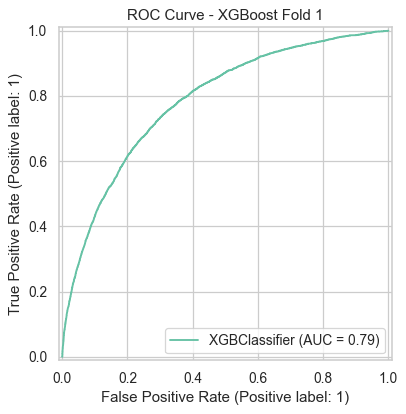

Random Forest - 
Accuracy: 0.7635, 
Precision: 0.1904, 
Recall: 0.5958, 
F1: 0.2886, 
F-beta: 0.4179, 
ROC AUC: 0.7640 
Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.78      0.86     45240
         1.0       0.19      0.60      0.29      3961

    accuracy                           0.76     49201
   macro avg       0.57      0.69      0.57     49201
weighted avg       0.89      0.76      0.81     49201
 
Confusion Matrix:
[[35207 10033]
 [ 1601  2360]]


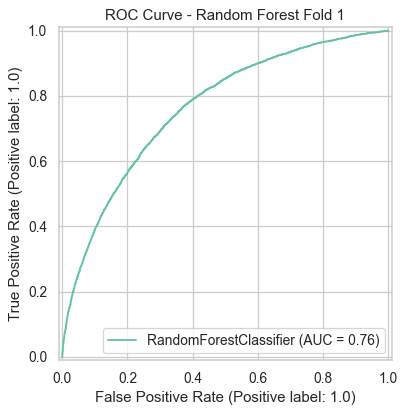

LightGBM - 
Accuracy: 0.7679, 
Precision: 0.2041, 
Recall: 0.6496, 
F1: 0.3106, 
F-beta: 0.4522, 
ROC AUC: 0.7891 
Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.78      0.86     45240
         1.0       0.20      0.65      0.31      3961

    accuracy                           0.77     49201
   macro avg       0.58      0.71      0.59     49201
weighted avg       0.90      0.77      0.82     49201
 
Confusion Matrix:
[[35206 10034]
 [ 1388  2573]]


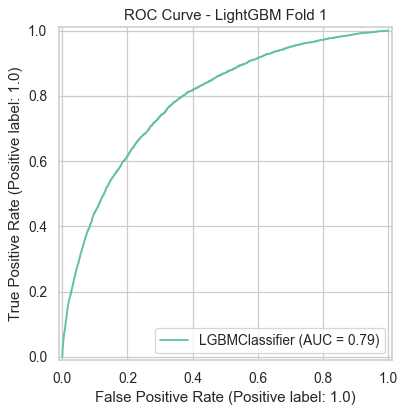

Calibrated LR - 
Accuracy: 0.9198, 
Precision: 0.5330, 
Recall: 0.0305, 
F1: 0.0578, 
F-beta: 0.0376, 
ROC AUC: 0.7765 
Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96     45240
         1.0       0.53      0.03      0.06      3961

    accuracy                           0.92     49201
   macro avg       0.73      0.51      0.51     49201
weighted avg       0.89      0.92      0.89     49201
 
Confusion Matrix:
[[45134   106]
 [ 3840   121]]


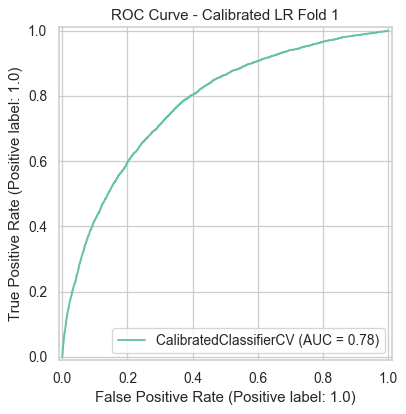

Fold 2/5
Training XGBoost...
Training Random Forest...
Training LightGBM...
[LightGBM] [Info] Number of positive: 15843, number of negative: 180961
[LightGBM] [Info] Total Bins 87250
[LightGBM] [Info] Number of data points in the train set: 196804, number of used features: 541
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080501 -> initscore=-2.435554
[LightGBM] [Info] Start training from score -2.435554
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

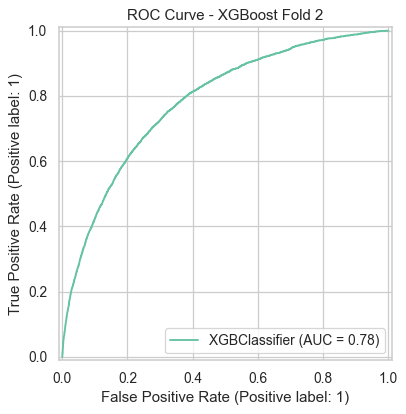

Random Forest - 
Accuracy: 0.7591, 
Precision: 0.1875, 
Recall: 0.5976, 
F1: 0.2854, 
F-beta: 0.4157, 
ROC AUC: 0.7570 
Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.77      0.86     45240
         1.0       0.19      0.60      0.29      3961

    accuracy                           0.76     49201
   macro avg       0.57      0.69      0.57     49201
weighted avg       0.89      0.76      0.81     49201
 
Confusion Matrix:
[[34981 10259]
 [ 1594  2367]]


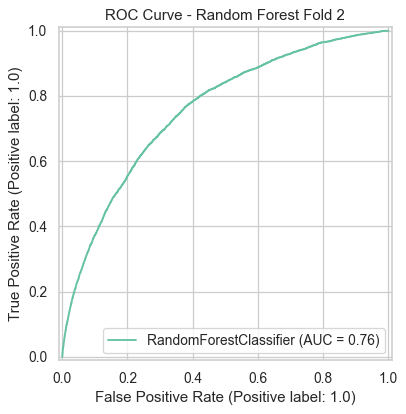

LightGBM - 
Accuracy: 0.7673, 
Precision: 0.2040, 
Recall: 0.6511, 
F1: 0.3106, 
F-beta: 0.4526, 
ROC AUC: 0.7878 
Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.78      0.86     45240
         1.0       0.20      0.65      0.31      3961

    accuracy                           0.77     49201
   macro avg       0.58      0.71      0.59     49201
weighted avg       0.90      0.77      0.82     49201
 
Confusion Matrix:
[[35175 10065]
 [ 1382  2579]]


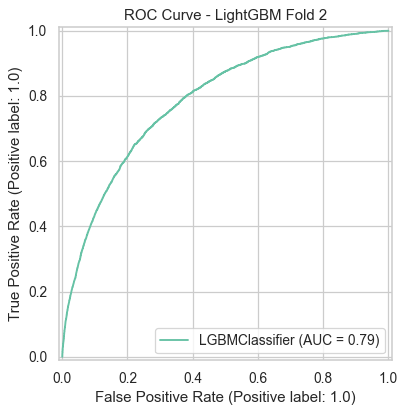

Calibrated LR - 
Accuracy: 0.9196, 
Precision: 0.5146, 
Recall: 0.0268, 
F1: 0.0509, 
F-beta: 0.0330, 
ROC AUC: 0.7780 
Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96     45240
         1.0       0.51      0.03      0.05      3961

    accuracy                           0.92     49201
   macro avg       0.72      0.51      0.50     49201
weighted avg       0.89      0.92      0.88     49201
 
Confusion Matrix:
[[45140   100]
 [ 3855   106]]


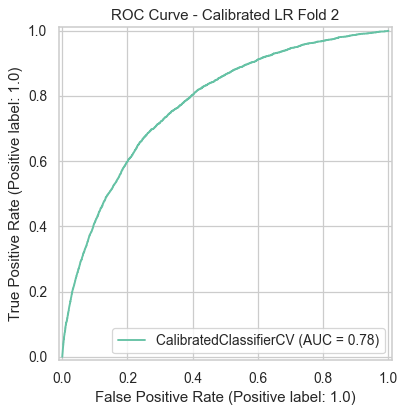

Fold 3/5
Training XGBoost...
Training Random Forest...
Training LightGBM...
[LightGBM] [Info] Number of positive: 15843, number of negative: 180961
[LightGBM] [Info] Total Bins 87334
[LightGBM] [Info] Number of data points in the train set: 196804, number of used features: 541
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080501 -> initscore=-2.435554
[LightGBM] [Info] Start training from score -2.435554
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

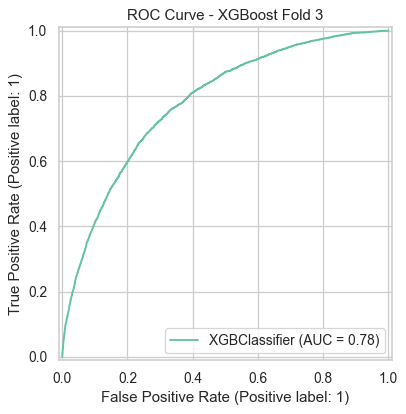

Random Forest - 
Accuracy: 0.7630, 
Precision: 0.1904, 
Recall: 0.5981, 
F1: 0.2889, 
F-beta: 0.4188, 
ROC AUC: 0.7601 
Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.78      0.86     45240
         1.0       0.19      0.60      0.29      3961

    accuracy                           0.76     49201
   macro avg       0.57      0.69      0.57     49201
weighted avg       0.90      0.76      0.81     49201
 
Confusion Matrix:
[[35170 10070]
 [ 1592  2369]]


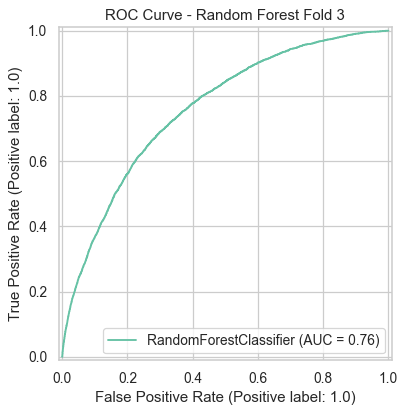

LightGBM - 
Accuracy: 0.7722, 
Precision: 0.2062, 
Recall: 0.6420, 
F1: 0.3121, 
F-beta: 0.4512, 
ROC AUC: 0.7889 
Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.78      0.86     45240
         1.0       0.21      0.64      0.31      3961

    accuracy                           0.77     49201
   macro avg       0.58      0.71      0.59     49201
weighted avg       0.90      0.77      0.82     49201
 
Confusion Matrix:
[[35448  9792]
 [ 1418  2543]]


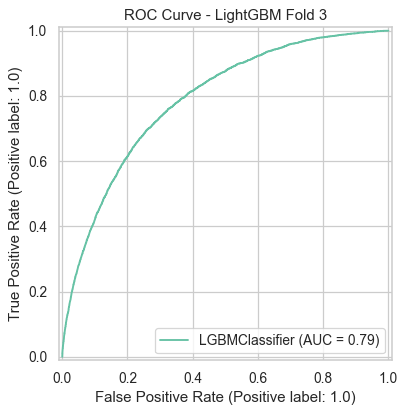

Calibrated LR - 
Accuracy: 0.9198, 
Precision: 0.5385, 
Recall: 0.0265, 
F1: 0.0505, 
F-beta: 0.0327, 
ROC AUC: 0.7762 
Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96     45240
         1.0       0.54      0.03      0.05      3961

    accuracy                           0.92     49201
   macro avg       0.73      0.51      0.50     49201
weighted avg       0.89      0.92      0.89     49201
 
Confusion Matrix:
[[45150    90]
 [ 3856   105]]


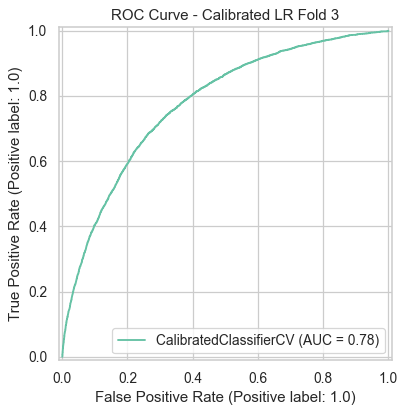

Fold 4/5
Training XGBoost...
Training Random Forest...
Training LightGBM...
[LightGBM] [Info] Number of positive: 15843, number of negative: 180961
[LightGBM] [Info] Total Bins 87248
[LightGBM] [Info] Number of data points in the train set: 196804, number of used features: 541
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080501 -> initscore=-2.435554
[LightGBM] [Info] Start training from score -2.435554
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

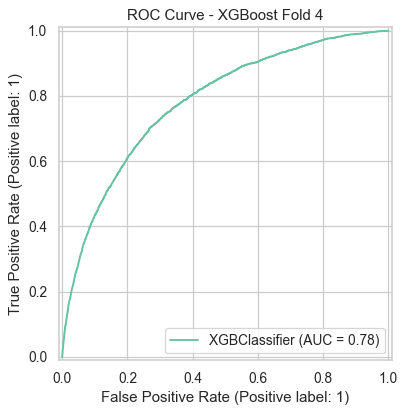

Random Forest - 
Accuracy: 0.7563, 
Precision: 0.1877, 
Recall: 0.6092, 
F1: 0.2870, 
F-beta: 0.4204, 
ROC AUC: 0.7576 
Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.77      0.85     45240
         1.0       0.19      0.61      0.29      3961

    accuracy                           0.76     49201
   macro avg       0.57      0.69      0.57     49201
weighted avg       0.90      0.76      0.81     49201
 
Confusion Matrix:
[[34799 10441]
 [ 1548  2413]]


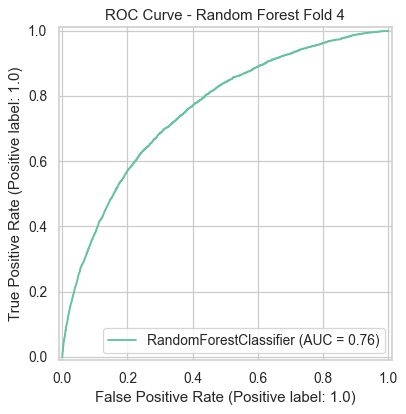

LightGBM - 
Accuracy: 0.7680, 
Precision: 0.2035, 
Recall: 0.6460, 
F1: 0.3096, 
F-beta: 0.4503, 
ROC AUC: 0.7873 
Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.78      0.86     45240
         1.0       0.20      0.65      0.31      3961

    accuracy                           0.77     49201
   macro avg       0.58      0.71      0.59     49201
weighted avg       0.90      0.77      0.82     49201
 
Confusion Matrix:
[[35227 10013]
 [ 1402  2559]]


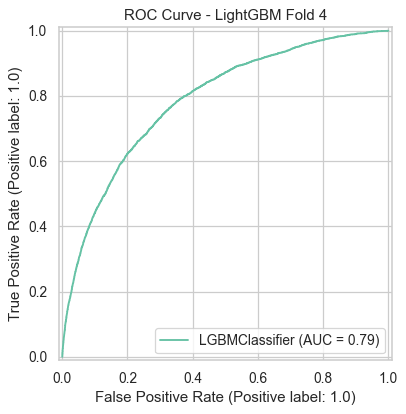

Calibrated LR - 
Accuracy: 0.9196, 
Precision: 0.5085, 
Recall: 0.0303, 
F1: 0.0572, 
F-beta: 0.0373, 
ROC AUC: 0.7758 
Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96     45240
         1.0       0.51      0.03      0.06      3961

    accuracy                           0.92     49201
   macro avg       0.72      0.51      0.51     49201
weighted avg       0.89      0.92      0.89     49201
 
Confusion Matrix:
[[45124   116]
 [ 3841   120]]


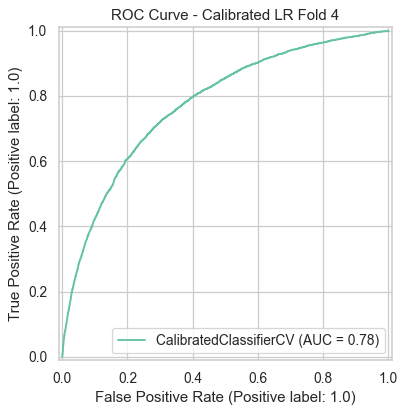

Fold 5/5
Training XGBoost...
Training Random Forest...
Training LightGBM...
[LightGBM] [Info] Number of positive: 15844, number of negative: 180960
[LightGBM] [Info] Total Bins 87285
[LightGBM] [Info] Number of data points in the train set: 196804, number of used features: 540
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080506 -> initscore=-2.435485
[LightGBM] [Info] Start training from score -2.435485
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

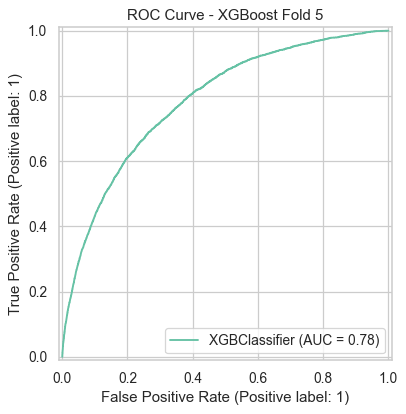

Random Forest - 
Accuracy: 0.7601, 
Precision: 0.1895, 
Recall: 0.6045, 
F1: 0.2886, 
F-beta: 0.4204, 
ROC AUC: 0.7628 
Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.77      0.86     45241
         1.0       0.19      0.60      0.29      3960

    accuracy                           0.76     49201
   macro avg       0.57      0.69      0.57     49201
weighted avg       0.90      0.76      0.81     49201
 
Confusion Matrix:
[[35005 10236]
 [ 1566  2394]]


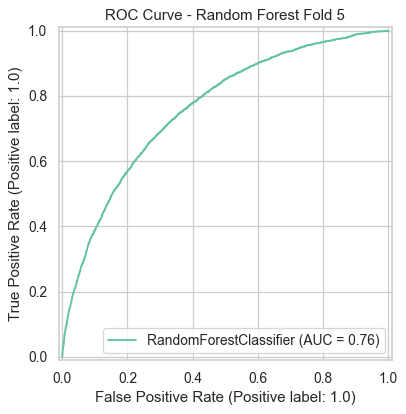

LightGBM - 
Accuracy: 0.7658, 
Precision: 0.2027, 
Recall: 0.6513, 
F1: 0.3092, 
F-beta: 0.4515, 
ROC AUC: 0.7901 
Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.78      0.86     45241
         1.0       0.20      0.65      0.31      3960

    accuracy                           0.77     49201
   macro avg       0.58      0.71      0.58     49201
weighted avg       0.90      0.77      0.81     49201
 
Confusion Matrix:
[[35097 10144]
 [ 1381  2579]]


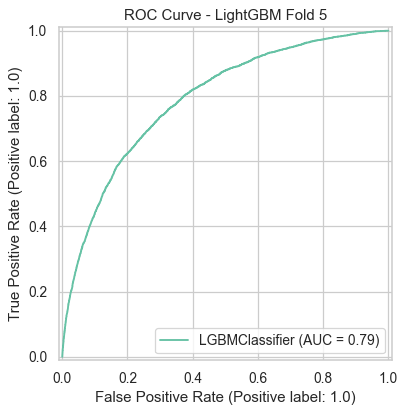

Calibrated LR - 
Accuracy: 0.9195, 
Precision: 0.4975, 
Recall: 0.0255, 
F1: 0.0485, 
F-beta: 0.0315, 
ROC AUC: 0.7798 
Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96     45241
         1.0       0.50      0.03      0.05      3960

    accuracy                           0.92     49201
   macro avg       0.71      0.51      0.50     49201
weighted avg       0.89      0.92      0.88     49201
 
Confusion Matrix:
[[45139   102]
 [ 3859   101]]


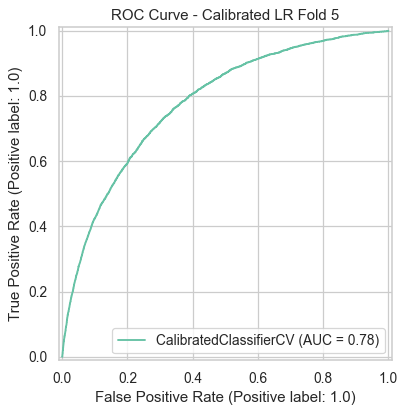


OOF summary (training portion)
  XGBoost      OOF ROC-AUC: 0.7833
  Random Forest OOF ROC-AUC: 0.7602
  LightGBM     OOF ROC-AUC: 0.7886
  Calibrated LR OOF ROC-AUC: 0.7772


In [79]:
# ── 5-fold Stratified CV: train base models & collect OOF probabilities ───────
# For each fold: fit XGB/RF/LGBM/**Calibrated LR** on 4 folds, predict the
# held-out fold, and store those predictions in the *_oof arrays. Because every
# training row is predicted exactly once while it is OUT of the training set,
# the OOF probabilities are leakage-free and are what the meta-learner trains on.
#

import time

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pre-allocate OOF and hard-pred arrays (one slot per training row, one array per model)
xgb_oof = np.zeros(len(X_train))
rf_oof  = np.zeros(len(X_train))
lgb_oof = np.zeros(len(X_train))
lr_oof  = np.zeros(len(X_train))   # NEW: calibrated LR OOF probabilities

xgb_preds = np.zeros(len(X_train))
rf_preds  = np.zeros(len(X_train))
lgb_preds = np.zeros(len(X_train))
lr_preds  = np.zeros(len(X_train))  # NEW: LR hard predictions for fold metrics

# Test-set probability containers (kept as lists — averaged later)
xgb_test_proba = []
rf_test_probas = []
lgb_test_probas = []
lr_test_probas = []                 # NEW

y_val_all = np.zeros(len(X_train))

# ─── Define base learners ONCE before the loop ────────────────────────────────
print("Creating XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=5,
    min_child_weight=1, gamma=0,
    subsample=0.8, colsample_bytree=0.8,
    objective="binary:logistic", eval_metric="auc",
    reg_alpha=0.1, reg_lambda=2,
    random_state=42,
    scale_pos_weight=11.4,
    # early_stopping_rounds=50,    # left off — would leak val fold info
)

print("Creating Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    min_samples_split=20, min_samples_leaf=10,
    random_state=42,
    class_weight="balanced",
    max_features="sqrt",
)

print("Creating LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=5,
    min_child_weight=1, min_child_samples=100,
    subsample=0.8, colsample_bytree=0.8,
    objective="binary", n_jobs=-1, random_state=42,
    reg_alpha=0.1, reg_lambda=1, num_leaves=20,
    force_col_wise=True, is_unbalance=True,
)

print("Calibrated LR will be (re)built per fold via build_calibrated_lr().")
print()

# ─── Train Models and Evaluate (fold loop) ────────────────────────────────────
for nfold, (train_idx, val_idx) in enumerate(CV.split(X_train, y_train), start=1):
    print("="*72)
    print(f"Fold {nfold}/5")
    print("="*72)
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # ─── Train XGBoost ────────────────────────────────────────────────────────
    print("Training XGBoost...")
    xgb_model.fit(X_train_fold, y_train_fold,
                   eval_set=[(X_val_fold, y_val_fold)], verbose=0)
    # Train Random Forest
    print("Training Random Forest...")
    rf_model.fit(X_train_fold, y_train_fold)
    # Train LightGBM
    print("Training LightGBM...")
    lgb_model.fit(X_train_fold, y_train_fold)
    # Train Calibrated LR (NEW)
    print("Training Calibrated LR...")
    lr_t0 = time.time()
    lr_model = build_calibrated_lr(C=0.1)
    lr_model.fit(X_train_fold, y_train_fold)
    print(f"  (LR fit time: {time.time() - lr_t0:.1f}s)")

    # ─── Evaluation Metrics for XGBoost ───────────────────────────────────────
    xgb_preds[val_idx] = xgb_model.predict(X_val_fold)
    xgb_proba          = xgb_model.predict_proba(X_val_fold)[:, 1]
    xgb_oof[val_idx]   = xgb_proba

    xgb_accuracy  = accuracy_score(y_val_fold,  xgb_preds[val_idx])
    xgb_precision = precision_score(y_val_fold, xgb_preds[val_idx])
    xgb_recall    = recall_score(y_val_fold,    xgb_preds[val_idx])
    xgb_f1        = f1_score(y_val_fold,        xgb_preds[val_idx])
    xgb_fbeta     = fbeta_score(y_val_fold,     xgb_preds[val_idx], beta=2)
    xgb_roc_auc   = roc_auc_score(y_val_fold,   xgb_proba)             # FIXED: was xgb_preds (hard)
    xgb_report    = classification_report(y_val_fold, xgb_preds[val_idx])
    xgb_conf_matrix = confusion_matrix(y_val_fold, xgb_preds[val_idx])
    print(f"XGBoost - \nAccuracy: {xgb_accuracy:.4f}, \nPrecision: {xgb_precision:.4f}, "
          f"\nRecall: {xgb_recall:.4f}, \nF1: {xgb_f1:.4f}, "
          f"\nF-beta: {xgb_fbeta:.4f}, \nROC AUC: {xgb_roc_auc:.4f}",
          f"\nClassification Report:\n{xgb_report}",
          f"\nConfusion Matrix:\n{xgb_conf_matrix}")
    RocCurveDisplay.from_estimator(xgb_model, X_val_fold, y_val_fold)
    plt.title(f"ROC Curve - XGBoost Fold {nfold}"); plt.show()

    # ─── Evaluation Metrics for Random Forest ─────────────────────────────────
    rf_preds[val_idx] = rf_model.predict(X_val_fold)
    rf_proba          = rf_model.predict_proba(X_val_fold)[:, 1]
    rf_oof[val_idx]   = rf_proba

    rf_accuracy  = accuracy_score(y_val_fold,  rf_preds[val_idx])
    rf_precision = precision_score(y_val_fold, rf_preds[val_idx])
    rf_recall    = recall_score(y_val_fold,    rf_preds[val_idx])
    rf_f1        = f1_score(y_val_fold,        rf_preds[val_idx])
    rf_fbeta     = fbeta_score(y_val_fold,     rf_preds[val_idx], beta=2)
    rf_roc_auc   = roc_auc_score(y_val_fold,   rf_proba)
    rf_report    = classification_report(y_val_fold, rf_preds[val_idx])
    rf_conf_matrix = confusion_matrix(y_val_fold, rf_preds[val_idx])
    print(f"Random Forest - \nAccuracy: {rf_accuracy:.4f}, \nPrecision: {rf_precision:.4f}, "
          f"\nRecall: {rf_recall:.4f}, \nF1: {rf_f1:.4f}, "
          f"\nF-beta: {rf_fbeta:.4f}, \nROC AUC: {rf_roc_auc:.4f}",
          f"\nClassification Report:\n{rf_report}",
          f"\nConfusion Matrix:\n{rf_conf_matrix}")
    RocCurveDisplay.from_estimator(rf_model, X_val_fold, y_val_fold)
    plt.title(f"ROC Curve - Random Forest Fold {nfold}"); plt.show()

    # ─── Evaluation Metrics for LightGBM ──────────────────────────────────────
    lgb_preds[val_idx] = lgb_model.predict(X_val_fold)
    lgb_proba          = lgb_model.predict_proba(X_val_fold)[:, 1]
    lgb_oof[val_idx]   = lgb_proba

    lgb_accuracy  = accuracy_score(y_val_fold,  lgb_preds[val_idx])
    lgb_precision = precision_score(y_val_fold, lgb_preds[val_idx])
    lgb_recall    = recall_score(y_val_fold,    lgb_preds[val_idx])
    lgb_f1        = f1_score(y_val_fold,        lgb_preds[val_idx])
    lgb_fbeta     = fbeta_score(y_val_fold,     lgb_preds[val_idx], beta=2)
    lgb_roc_auc   = roc_auc_score(y_val_fold,   lgb_proba)
    lgb_report    = classification_report(y_val_fold, lgb_preds[val_idx])
    lgb_conf_matrix = confusion_matrix(y_val_fold, lgb_preds[val_idx])
    print(f"LightGBM - \nAccuracy: {lgb_accuracy:.4f}, \nPrecision: {lgb_precision:.4f}, "
          f"\nRecall: {lgb_recall:.4f}, \nF1: {lgb_f1:.4f}, "
          f"\nF-beta: {lgb_fbeta:.4f}, \nROC AUC: {lgb_roc_auc:.4f}",
          f"\nClassification Report:\n{lgb_report}",
          f"\nConfusion Matrix:\n{lgb_conf_matrix}")
    RocCurveDisplay.from_estimator(lgb_model, X_val_fold, y_val_fold)
    plt.title(f"ROC Curve - LightGBM Fold {nfold}"); plt.show()

    # ─── Evaluation Metrics for Calibrated LR (NEW) ───────────────────────────
    lr_preds[val_idx] = lr_model.predict(X_val_fold)
    lr_proba          = lr_model.predict_proba(X_val_fold)[:, 1]
    lr_oof[val_idx]   = lr_proba

    lr_accuracy  = accuracy_score(y_val_fold,  lr_preds[val_idx])
    lr_precision = precision_score(y_val_fold, lr_preds[val_idx])
    lr_recall    = recall_score(y_val_fold,    lr_preds[val_idx])
    lr_f1        = f1_score(y_val_fold,        lr_preds[val_idx])
    lr_fbeta     = fbeta_score(y_val_fold,     lr_preds[val_idx], beta=2)
    lr_roc_auc   = roc_auc_score(y_val_fold,   lr_proba)   # uses calibrated soft probs
    lr_report    = classification_report(y_val_fold, lr_preds[val_idx])
    lr_conf_matrix = confusion_matrix(y_val_fold, lr_preds[val_idx])
    print(f"Calibrated LR - \nAccuracy: {lr_accuracy:.4f}, \nPrecision: {lr_precision:.4f}, "
          f"\nRecall: {lr_recall:.4f}, \nF1: {lr_f1:.4f}, "
          f"\nF-beta: {lr_fbeta:.4f}, \nROC AUC: {lr_roc_auc:.4f}",
          f"\nClassification Report:\n{lr_report}",
          f"\nConfusion Matrix:\n{lr_conf_matrix}")
    RocCurveDisplay.from_estimator(lr_model, X_val_fold, y_val_fold)
    plt.title(f"ROC Curve - Calibrated LR Fold {nfold}"); plt.show()

print()
print("="*72)
print("OOF summary (training portion)")
print("="*72)
print(f"  XGBoost      OOF ROC-AUC: {roc_auc_score(y_train, xgb_oof):.4f}")
print(f"  Random Forest OOF ROC-AUC: {roc_auc_score(y_train, rf_oof):.4f}")
print(f"  LightGBM     OOF ROC-AUC: {roc_auc_score(y_train, lgb_oof):.4f}")
print(f"  Calibrated LR OOF ROC-AUC: {roc_auc_score(y_train, lr_oof):.4f}")


In [80]:
# ── Meta-learner definition ───────────────────────────────────────────────────
# A small MLP (32→16, ReLU, Adam) that learns the optimal non-linear combination
# of the three base-model OOF probabilities. early_stopping guards against
# overfitting the tiny 3-feature meta dataset.

from sklearn.neural_network import MLPClassifier
meta_model = MLPClassifier(
    hidden_layer_sizes=(32,16),
    activation='relu',
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42,
    n_iter_no_change=10,
    alpha=1e-3,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=True
)


In [81]:
# ── Assemble the meta-learner TRAINING matrix from OOF probabilities ──────────
# Each column is one base model's out-of-fold probability for the positive class.
#

# Data set for Meta learner
x_meta = np.column_stack([
    xgb_oof,   # col 0: XGBoost
    rf_oof,    # col 1: Random Forest
    lgb_oof,   # col 2: LightGBM
    lr_oof,    # col 3: Calibrated LR (NEW)
])
y_meta = y_train.values
print("x_meta shape:", x_meta.shape, "  (n_samples, n_base_models)")
print("y_meta shape:", y_meta.shape)

# Diversity diagnostic — low correlation between OOF columns = good for stacking
oof_corr = pd.DataFrame({
    "xgb": xgb_oof, "rf": rf_oof, "lgb": lgb_oof, "lr": lr_oof
}).corr()
print()
print("Base-learner OOF correlation matrix:")
print(oof_corr.round(4))


x_meta shape: (246005, 4)   (n_samples, n_base_models)
y_meta shape: (246005,)

Base-learner OOF correlation matrix:
        xgb      rf     lgb      lr
xgb  1.0000  0.9145  0.9475  0.8086
rf   0.9145  1.0000  0.8687  0.7697
lgb  0.9475  0.8687  1.0000  0.8070
lr   0.8086  0.7697  0.8070  1.0000


In [82]:
# Sanity check on the holdout shapes before scoring.

print(X_test.shape)
print(y_test.shape)

(61502, 603)
(61502,)


Iteration 1, loss = 0.56295729
Validation score: 0.721094
Iteration 2, loss = 0.55457002
Validation score: 0.721094
Iteration 3, loss = 0.55432810
Validation score: 0.721072
Iteration 4, loss = 0.55429957
Validation score: 0.721845
Iteration 5, loss = 0.55423841
Validation score: 0.721757
Iteration 6, loss = 0.55420716
Validation score: 0.721005
Iteration 7, loss = 0.55418678
Validation score: 0.721116
Iteration 8, loss = 0.55413774
Validation score: 0.721182
Iteration 9, loss = 0.55423216
Validation score: 0.721381
Iteration 10, loss = 0.55419449
Validation score: 0.721845
Iteration 11, loss = 0.55409382
Validation score: 0.722155
Iteration 12, loss = 0.55404582
Validation score: 0.721978
Iteration 13, loss = 0.55402791
Validation score: 0.721978
Iteration 14, loss = 0.55395912
Validation score: 0.722155
Iteration 15, loss = 0.55389984
Validation score: 0.722995
Iteration 16, loss = 0.55381282
Validation score: 0.721271
Iteration 17, loss = 0.55376992
Validation score: 0.722420
Iterat

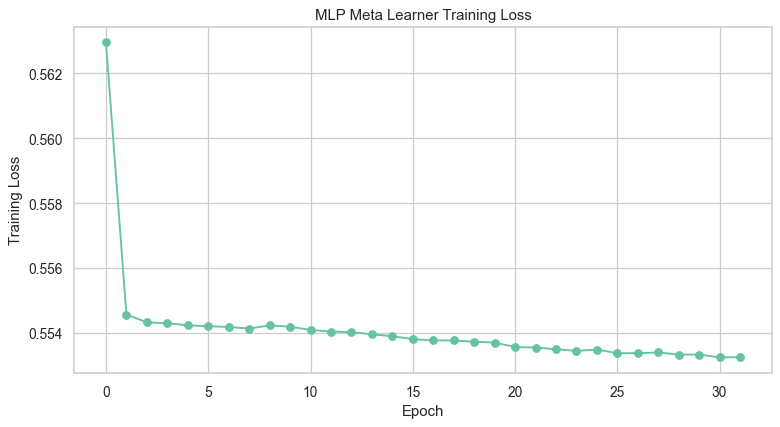

Best F2 Score: 0.4555 at Threshold: 0.5091
At this threshold, Precision: 0.1882, Recall: 0.7064
Best F1 Score: 0.3421 at Threshold: 0.7054
At this threshold, Precision: 0.2759, Recall: 0.4501
Meta Model Accuracy: 0.7310095323265787


In [83]:
# ── Train meta-learner + tune the decision threshold ──────────────────────────
# SMOTE balances the meta TRAINING data only (never the held-out data), then the
# MLP is fit. Using the precision-recall curve we search for the threshold that
# maximises F2 (recall-weighted) and, separately, F1 (balanced). F2 is chosen
# because missing a defaulter is the costlier error in credit risk.
#

# Perform SMOTE to balance the meta training data
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_meta_smoted, y_meta_smoted = smote.fit_resample(x_meta, y_meta)

# Train meta learner
meta_model.fit(x_meta_smoted, y_meta_smoted)

plt.figure(figsize=(10, 5))
plt.plot(meta_model.loss_curve_, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MLP Meta Learner Training Loss")
plt.grid(True)
plt.show()

# Get probabilities on ORIGINAL meta training data for threshold search
meta_proba = meta_model.predict_proba(x_meta)[:, 1]

# Optimize F2 score by finding the best threshold
from sklearn.metrics import precision_recall_curve
mlp_precision, mlp_recall, mlp_thresholds = precision_recall_curve(y_meta, meta_proba)
f2_scores = (5 * mlp_precision * mlp_recall) / (4 * mlp_precision + mlp_recall + 1e-10)  # Adding small epsilon to avoid division by zero
best_f2_idx = np.argmax(f2_scores)
best_f2_threshold = mlp_thresholds[best_f2_idx]
print(f"Best F2 Score: {f2_scores[best_f2_idx]:.4f} at Threshold: {best_f2_threshold:.4f}")
print(f"At this threshold, Precision: {mlp_precision[best_f2_idx]:.4f}, Recall: {mlp_recall[best_f2_idx]:.4f}")

# Optimize F1 score by finding the best threshold (balanced precision and recall)
f1_scores = 2 * (mlp_precision * mlp_recall) / (mlp_precision + mlp_recall + 1e-8)
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = mlp_thresholds[best_f1_idx]
print(f"Best F1 Score: {f1_scores[best_f1_idx]:.4f} at Threshold: {best_f1_threshold:.4f}")
print(f"At this threshold, Precision: {mlp_precision[best_f1_idx]:.4f}, Recall: {mlp_recall[best_f1_idx]:.4f}")

# Apply chosen threshold to get final predictions on ORIGINAL meta data
chosen_threshold = best_f2_threshold  # or best_f1_threshold based on your preference
final_meta_preds = (meta_proba >= chosen_threshold).astype(int)

# Accuracy check uses original labels to match prediction length
from sklearn.metrics import accuracy_score, precision_recall_curve

print(
    "Meta Model Accuracy:",
    accuracy_score(y_meta, final_meta_preds)
)

In [84]:
# ── Refit base models on the full local training split ────────────────────────
# Before scoring the holdout, the base models are refit on the entire 80%
# training slice. The CV-fold models only saw 4/5 of the data; these "full-80%"
# models are what generate the holdout predictions consumed by the meta-learner.
#
# The meta-learner itself stays trained on the OOF predictions — do NOT refit
# the MLP on these in-sample base predictions or it will overfit.

# Train all base learners on the whole 80% training data
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
lgb_model.fit(X_train, y_train)

# Calibrated LR — refit on the full 80% as well (NEW)
print("Refitting calibrated LR on full 80% ...")
import time
t0 = time.time()
lr_model_full = build_calibrated_lr(C=0.1)
lr_model_full.fit(X_train, y_train)
print(f"Calibrated LR refit time: {time.time() - t0:.1f}s")


[LightGBM] [Info] Number of positive: 19804, number of negative: 226201
[LightGBM] [Info] Total Bins 87307
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 543
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080502 -> initscore=-2.435540
[LightGBM] [Info] Start training from score -2.435540
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [85]:
# ── Build the meta-learner TEST matrix from base-model holdout probabilities ──
#

xgb_test_preds = xgb_model.predict_proba(X_test)[:, 1]
rf_test_preds  = rf_model.predict_proba(X_test)[:, 1]
lgb_test_preds = lgb_model.predict_proba(X_test)[:, 1]
lr_test_preds  = lr_model_full.predict_proba(X_test)[:, 1]   # NEW: calibrated LR holdout probs

# Data set for Meta learner — SAME column order as x_meta above
x_test_meta = np.column_stack([
    xgb_test_preds,   # col 0: XGBoost (matches x_meta col 0)
    rf_test_preds,    # col 1: Random Forest (matches x_meta col 1)
    lgb_test_preds,   # col 2: LightGBM (matches x_meta col 2)
    lr_test_preds,    # col 3: Calibrated LR (matches x_meta col 3, NEW)
])
y_test_meta = y_test
print("x_test_meta shape:", x_test_meta.shape)
print("y_test_meta shape:", y_test_meta.shape)


x_test_meta shape: (61502, 4)
y_test_meta shape: (61502,)


In [ ]:
# ── Final evaluation on the holdout ───────────────────────────────────────────
# Apply the F2-tuned threshold to the meta-learner's probabilities and report the
# full metric suite (Accuracy / Precision / Recall / F1 / ROC-AUC) plus the
# confusion matrix and ROC curve. Recall and F2 are the headline numbers for this
# imbalanced problem.

# accuarcy of meta lerner
# Predict on meta test data
# meta_preds = meta_model.predict(x_test_meta)
meta_proba = meta_model.predict_proba(x_test_meta)[:, 1]
#print(meta_proba.shape)
#print(meta_preds.shape)
#auc = roc_auc_score(y_test_meta, meta_proba)

# Apply the same threshold optimization on test data
final_test_meta_preds = (meta_proba >= chosen_threshold).astype(int)
auc = roc_auc_score(y_test_meta, meta_proba)
mlp_precision, mlp_recall, _ = precision_recall_curve(y_test_meta, meta_proba)
mlp_pr_auc = sk_auc(mlp_recall, mlp_precision)

print("Accuracy :", accuracy_score(y_test_meta, final_test_meta_preds))
print("Precision:", precision_score(y_test_meta, final_test_meta_preds))
print("Recall   :", recall_score(y_test_meta, final_test_meta_preds))
print("F1 Score :", f1_score(y_test_meta, final_test_meta_preds))
print("F2 Score :", fbeta_score(y_test_meta, final_test_meta_preds, beta=2))
print("PR AUC :", mlp_pr_auc)
print("ROC AUC :",auc)


print("\nConfusion Matrix")
print(confusion_matrix(y_test_meta, final_test_meta_preds))

# ROC AUC Curve for Meta Learner
RocCurveDisplay.from_estimator(meta_model, x_test_meta, y_test_meta)
plt.title(f"ROC AUC Curve - Meta Learner")
plt.show()


TypeError: 'float' object is not callable